In [2]:
# Om något bibliotek saknas:
# !pip install pandas numpy matplotlib tqdm openpyxl

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

pd.set_option("display.max_columns", None)
pd.options.mode.chained_assignment = None

# ============================================================
# FILVÄGAR OCH BLADNAMN
# ============================================================

send_file = r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\send-station.xlsx"
rec_file  = r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\rec-station.xlsx"

keyS_sheet  = "K-nyckel"
dataS_sheet = "Station_K_3x15000"

keyR_sheet  = "F-nyckel"
dataR_sheet = "Station_F_3x15000"

print("send finns:", os.path.exists(send_file))
print("rec finns :", os.path.exists(rec_file))

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def read_key_table_safe(filename, sheetname):
    T = pd.read_excel(filename, sheet_name=sheetname, header=None)
    T = T.iloc[:, :2].copy()
    T.columns = ["Parameter", "ID"]
    T = T.dropna()
    return T

def ls_diagnostics(A, Y, beta):
    Y_hat = A @ beta
    resid = Y - Y_hat

    n = len(Y)
    p = A.shape[1]
    dof = max(n - p, 1)

    sigma2 = np.sum(resid**2) / dof
    ATA_inv = np.linalg.pinv(A.T @ A)
    cov_beta = sigma2 * ATA_inv
    se_beta = np.sqrt(np.diag(cov_beta))

    return {
        "residuals_vector": resid,
        "sigma2": sigma2,
        "cov_beta": cov_beta,
        "se_beta": se_beta,
        "dof": dof
    }

def estimate_B_and_K1_3ph(vs_dict, vr_dict, is_dict, ir_dict):
    """
    Full simultan trefas steg 1.

    Parametrar:
    beta1 = [
        Re(K1_L1), Re(K1_L2), Re(K1_L3),
        Im(K1_L1), Im(K1_L2), Im(K1_L3),
        B_L1,      B_L2,      B_L3
    ]
    """
    phases = ["L1", "L2", "L3"]

    Y_parts = []
    A_rows = []

    for ph_idx, ph in enumerate(phases):
        vs = vs_dict[ph]
        vr = vr_dict[ph]
        is_ = is_dict[ph]
        ir = ir_dict[ph]

        ir_re = np.real(ir)
        ir_im = np.imag(ir)

        v_sum = vs + vr
        v_re = np.real(v_sum)
        v_im = np.imag(v_sum)

        # Realdel för denna fas
        for k in range(len(vs)):
            row = np.zeros(9)
            row[ph_idx] = ir_re[k]          # Re(K1_ph)
            row[3 + ph_idx] = -ir_im[k]     # Im(K1_ph)
            row[6 + ph_idx] = 0.5 * v_re[k] # B_ph
            A_rows.append(row)
            Y_parts.append(np.real(is_[k]))

        # Imaginärdel för denna fas
        for k in range(len(vs)):
            row = np.zeros(9)
            row[ph_idx] = ir_im[k]          # Re(K1_ph)
            row[3 + ph_idx] = ir_re[k]      # Im(K1_ph)
            row[6 + ph_idx] = 0.5 * v_im[k] # B_ph
            A_rows.append(row)
            Y_parts.append(np.imag(is_[k]))

    A = np.array(A_rows)
    Y = np.array(Y_parts)

    beta, residuals, rank, s = np.linalg.lstsq(A, Y, rcond=None)
    diag = ls_diagnostics(A, Y, beta)

    return {
        "beta": beta,
        "rank": rank,
        "singular_values": s,
        "A": A,
        "Y": Y,
        "cov_beta": diag["cov_beta"],
        "se_beta": diag["se_beta"],
        "sigma2": diag["sigma2"]
    }

def estimate_Z_and_K4_3ph(vs_dict, vr_dict, ir_dict, B_dict):
    """
    Full simultan trefas steg 2.

    Parametrar:
    beta2 = [
        Re(K4_L1), Re(K4_L2), Re(K4_L3),
        Im(K4_L1), Im(K4_L2), Im(K4_L3),
        R_L1,      R_L2,      R_L3,
        X_L1,      X_L2,      X_L3
    ]
    """
    phases = ["L1", "L2", "L3"]

    Y_parts = []
    A_rows = []

    Ieq_dict = {}

    for ph in phases:
        Ieq_dict[ph] = ir_dict[ph] + 1j * (B_dict[ph] / 2.0) * vr_dict[ph]

    for ph_idx, ph in enumerate(phases):
        vs = vs_dict[ph]
        vr = vr_dict[ph]
        Ieq = Ieq_dict[ph]

        vr_re = np.real(vr)
        vr_im = np.imag(vr)

        ieq_re = np.real(Ieq)
        ieq_im = np.imag(Ieq)

        # Realdel
        for k in range(len(vs)):
            row = np.zeros(12)
            row[ph_idx] = vr_re[k]            # Re(K4_ph)
            row[3 + ph_idx] = -vr_im[k]       # Im(K4_ph)
            row[6 + ph_idx] = ieq_re[k]       # R_ph
            row[9 + ph_idx] = -ieq_im[k]      # X_ph
            A_rows.append(row)
            Y_parts.append(np.real(vs[k]))

        # Imaginärdel
        for k in range(len(vs)):
            row = np.zeros(12)
            row[ph_idx] = vr_im[k]            # Re(K4_ph)
            row[3 + ph_idx] = vr_re[k]        # Im(K4_ph)
            row[6 + ph_idx] = ieq_im[k]       # R_ph
            row[9 + ph_idx] = ieq_re[k]       # X_ph
            A_rows.append(row)
            Y_parts.append(np.imag(vs[k]))

    A = np.array(A_rows)
    Y = np.array(Y_parts)

    beta, residuals, rank, s = np.linalg.lstsq(A, Y, rcond=None)
    diag = ls_diagnostics(A, Y, beta)

    return {
        "beta": beta,
        "rank": rank,
        "singular_values": s,
        "A": A,
        "Y": Y,
        "Ieq_dict": Ieq_dict,
        "cov_beta": diag["cov_beta"],
        "se_beta": diag["se_beta"],
        "sigma2": diag["sigma2"]
    }


send finns: True
rec finns : True


In [3]:
# ============================================================
# LÄS NYCKLAR OCH RÅDATA
# ============================================================

keyS = read_key_table_safe(send_file, keyS_sheet)
keyR = read_key_table_safe(rec_file, keyR_sheet)

send = pd.read_excel(send_file, sheet_name=dataS_sheet, header=None)
rec  = pd.read_excel(rec_file,  sheet_name=dataR_sheet, header=None)

send = send.iloc[:, :3].copy()
rec  = rec.iloc[:, :3].copy()

send.columns = ["Timestamp", "ID", "Value"]
rec.columns  = ["Timestamp", "ID", "Value"]

send["Timestamp"] = pd.to_datetime(
    send["Timestamp"],
    format="%Y-%m-%d %H:%M:%S.%f",
    errors="coerce"
)

rec["Timestamp"] = pd.to_datetime(
    rec["Timestamp"],
    format="%Y-%m-%d %H:%M:%S.%f",
    errors="coerce"
)

send = send.dropna(subset=["Timestamp"])
rec  = rec.dropna(subset=["Timestamp"])

print("send tidsintervall:", send["Timestamp"].min(), "->", send["Timestamp"].max())
print("rec  tidsintervall:", rec["Timestamp"].min(), "->", rec["Timestamp"].max())
print("unika timestamps send:", send["Timestamp"].nunique())
print("unika timestamps rec :", rec["Timestamp"].nunique())

# ============================================================
# MAPPA ID TILL PARAMETER, PIVOTERA OCH SYNKA
# ============================================================

send = send.merge(keyS, on="ID", how="inner")
rec  = rec.merge(keyR, on="ID", how="inner")

wideS = send.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")
wideR = rec.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")

wideS = wideS.add_suffix("_S")
wideR = wideR.add_suffix("_R")

df = wideS.join(wideR, how="inner").sort_index().copy()

print("Antal rader wideS:", len(wideS))
print("Antal rader wideR:", len(wideR))
print("Gemensamma timestamps efter join:", len(df))

# ============================================================
# RENSNING
# ============================================================

required_cols = [
    "UL1MAG_S","UL1ANG_S","UL1MAG_R","UL1ANG_R",
    "IL1MAG_S","IL1ANG_S","IL1MAG_R","IL1ANG_R",
    "UL2MAG_S","UL2ANG_S","UL2MAG_R","UL2ANG_R",
    "IL2MAG_S","IL2ANG_S","IL2MAG_R","IL2ANG_R",
    "UL3MAG_S","UL3ANG_S","UL3MAG_R","UL3ANG_R",
    "IL3MAG_S","IL3ANG_S","IL3MAG_R","IL3ANG_R",
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Saknade kolumner: {missing}")

for c in required_cols:
    df[c] = (
        df[c]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False)
    )
    df[c] = pd.to_numeric(df[c], errors="coerce")

df_clean = df.dropna(subset=required_cols).copy()

print("Rader efter rensning:", len(df_clean))
print("Start:", df_clean.index.min())
print("Slut :", df_clean.index.max())
print("Tidslängd:", df_clean.index.max() - df_clean.index.min())

# ============================================================
# BYGG FASORER - MED INVERTERAD MOTTAGARSTRÖM
# ============================================================

phasors = {}

for ph in ["L1", "L2", "L3"]:
    Vs = df_clean[f"U{ph}MAG_S"] * np.exp(1j * np.deg2rad(df_clean[f"U{ph}ANG_S"]))
    Vr = df_clean[f"U{ph}MAG_R"] * np.exp(1j * np.deg2rad(df_clean[f"U{ph}ANG_R"]))
    Is = df_clean[f"I{ph}MAG_S"] * np.exp(1j * np.deg2rad(df_clean[f"I{ph}ANG_S"]))
    Ir = -df_clean[f"I{ph}MAG_R"] * np.exp(1j * np.deg2rad(df_clean[f"I{ph}ANG_R"]))  # inverterad

    phasors[ph] = {
        "Vs": Vs,
        "Vr": Vr,
        "Is": Is,
        "Ir": Ir,
    }

print("Fasorer skapade för:", list(phasors.keys()))
print("Mottagarström Ir har inverterats.")


send tidsintervall: 2025-12-11 15:25:02.469999 -> 2025-12-11 15:27:32.460000
rec  tidsintervall: 2025-12-11 15:25:02.469999 -> 2025-12-11 15:27:32.459999
unika timestamps send: 15000
unika timestamps rec : 15000
Antal rader wideS: 15000
Antal rader wideR: 15000
Gemensamma timestamps efter join: 7669
Rader efter rensning: 7669
Start: 2025-12-11 15:25:02.469999
Slut : 2025-12-11 15:27:32.450000
Tidslängd: 0 days 00:02:29.980001
Fasorer skapade för: ['L1', 'L2', 'L3']
Mottagarström Ir har inverterats.


In [4]:
# ============================================================
# FÖNSTERINSTÄLLNINGAR
# ============================================================

dt = df_clean.index.to_series().diff().dropna().dt.total_seconds()

print(dt.describe())
print("\nVanligaste tidssteg:")
print(dt.value_counts().head(10))

fs = 1.0 / dt.median()
print(f"\nUppskattad samplingsfrekvens fs = {fs:.3f} Hz")

window_seconds = 120
step_seconds = 5

WINDOW = int(round(window_seconds * fs))
STEP   = int(round(step_seconds * fs))

R_ref = 1.2575
alpha = 0.00403

N = len(df_clean)

print("N =", N)
print("WINDOW =", WINDOW)
print("STEP =", STEP)

if N <= WINDOW:
    raise ValueError(f"För få datapunkter. N={N}, WINDOW={WINDOW}")

idx = np.arange(0, N - WINDOW + 1, STEP)
print("Antal glidfönster =", len(idx))

# ============================================================
# KÖR FULL TREFAS SIMULTAN SINGH
# ============================================================

rows_3ph = []

for i in tqdm(idx, desc="3-ph Singh simultaneous"):
    i0 = i
    i1 = i + WINDOW

    vs_dict = {}
    vr_dict = {}
    is_dict = {}
    ir_dict = {}

    for ph in ["L1", "L2", "L3"]:
        vs_dict[ph] = phasors[ph]["Vs"].iloc[i0:i1].to_numpy()
        vr_dict[ph] = phasors[ph]["Vr"].iloc[i0:i1].to_numpy()
        is_dict[ph] = phasors[ph]["Is"].iloc[i0:i1].to_numpy()
        ir_dict[ph] = phasors[ph]["Ir"].iloc[i0:i1].to_numpy()

    try:
        # Steg 1
        res1 = estimate_B_and_K1_3ph(vs_dict, vr_dict, is_dict, ir_dict)
        beta1 = res1["beta"]

        K1 = {
            "L1": beta1[0] + 1j * beta1[3],
            "L2": beta1[1] + 1j * beta1[4],
            "L3": beta1[2] + 1j * beta1[5],
        }

        B = {
            "L1": beta1[6],
            "L2": beta1[7],
            "L3": beta1[8],
        }

        # Steg 2
        res2 = estimate_Z_and_K4_3ph(vs_dict, vr_dict, ir_dict, B)
        beta2 = res2["beta"]

        K4 = {
            "L1": beta2[0] + 1j * beta2[3],
            "L2": beta2[1] + 1j * beta2[4],
            "L3": beta2[2] + 1j * beta2[5],
        }

        R = {
            "L1": beta2[6],
            "L2": beta2[7],
            "L3": beta2[8],
        }

        X = {
            "L1": beta2[9],
            "L2": beta2[10],
            "L3": beta2[11],
        }

    except np.linalg.LinAlgError:
        continue

    center_ts = df_clean.index[i0 + WINDOW // 2]

    for ph_idx, ph in enumerate(["L1", "L2", "L3"]):
        se_R = res2["se_beta"][6 + ph_idx]
        se_X = res2["se_beta"][9 + ph_idx]

        T_est = ((R[ph] / R_ref) - 1.0) / alpha + 20.0

        dT_dR = 1.0 / (alpha * R_ref)
        u_T = abs(dT_dR) * se_R

        rows_3ph.append({
            "Timestamp": center_ts,
            "Phase": ph,
            "K1_real": np.real(K1[ph]),
            "K1_imag": np.imag(K1[ph]),
            "K4_real": np.real(K4[ph]),
            "K4_imag": np.imag(K4[ph]),
            "B_S": B[ph],
            "R_Ohm": R[ph],
            "X_Ohm": X[ph],
            "u_R_Ohm": se_R,
            "u_X_Ohm": se_X,
            "T_C": T_est,
            "u_T_C": u_T,
            "rank_step1": res1["rank"],
            "rank_step2": res2["rank"]
        })

results_3ph_long = pd.DataFrame(rows_3ph)

print("Antal rader i results_3ph_long:", len(results_3ph_long))
display(results_3ph_long.head())


count    7668.000000
mean        0.019559
std         0.012780
min         0.009998
25%         0.010000
50%         0.019999
75%         0.030000
max         0.140000
Name: Timestamp, dtype: float64

Vanligaste tidssteg:
Timestamp
0.010000    2608
0.030000    1448
0.020000    1438
0.009999     528
0.010001     513
0.020001     292
0.019999     241
0.060000     134
0.040000     119
0.050000      94
Name: count, dtype: int64

Uppskattad samplingsfrekvens fs = 50.003 Hz
N = 7669
WINDOW = 6000
STEP = 250
Antal glidfönster = 7


3-ph Singh simultaneous:   0%|          | 0/7 [00:00<?, ?it/s]

Antal rader i results_3ph_long: 21


,Timestamp,Phase,K1_real,K1_imag,K4_real,K4_imag,B_S,R_Ohm,X_Ohm,u_R_Ohm,u_X_Ohm,T_C,u_T_C,rank_step1,rank_step2
0,2025-12-11 15:26:04.179999,L1,1.002441,0.017093,0.999619,0.000834,0.000016,1.932270,6.411183,0.010053,0.010053,153.150549,1.983805,9,12
1,2025-12-11 15:26:04.179999,L2,0.994724,0.015430,0.999508,0.000744,0.000037,1.333256,5.994489,0.009991,0.009991,34.948778,1.971463,9,12
2,2025-12-11 15:26:04.179999,L3,0.984783,0.021669,0.999391,0.000994,0.000064,0.820024,6.372456,0.010036,0.010036,-66.325941,1.980356,9,12
3,2025-12-11 15:26:08.649999,L1,1.002742,0.017121,0.999611,0.000919,0.000015,1.935204,6.375761,0.010385,0.010385,153.729447,2.049289,9,12
4,2025-12-11 15:26:08.649999,L2,0.994742,0.015541,0.999544,0.000854,0.000037,1.320979,5.949960,0.010314,0.010314,32.526161,2.035270,9,12


In [5]:
# ============================================================
# BRETT FORMAT
# ============================================================

out_3ph = results_3ph_long.pivot(
    index="Timestamp",
    columns="Phase",
    values=[
        "K1_real", "K1_imag",
        "K4_real", "K4_imag",
        "B_S", "R_Ohm", "X_Ohm",
        "u_R_Ohm", "u_X_Ohm",
        "T_C", "u_T_C"
    ]
)

out_3ph.columns = [f"{var}_{ph}" for var, ph in out_3ph.columns]
out_3ph = out_3ph.reset_index().sort_values("Timestamp")

print("HEAD out_3ph:")
display(out_3ph.head())

# Filtrera bort första fönstret för jämförbarhet
out_3ph_filtered = out_3ph.iloc[1:].copy()

print("HEAD out_3ph_filtered:")
display(out_3ph_filtered.head())

# ============================================================
# SUMMARY
# ============================================================

summary_3ph_rows = []

for ph in ["L1", "L2", "L3"]:
    summary_3ph_rows.append({
        "Phase": ph,
        "R_mean_Ohm": out_3ph_filtered[f"R_Ohm_{ph}"].mean(),
        "R_std_Ohm": out_3ph_filtered[f"R_Ohm_{ph}"].std(),
        "R_min_Ohm": out_3ph_filtered[f"R_Ohm_{ph}"].min(),
        "R_max_Ohm": out_3ph_filtered[f"R_Ohm_{ph}"].max(),
        "X_mean_Ohm": out_3ph_filtered[f"X_Ohm_{ph}"].mean(),
        "X_std_Ohm": out_3ph_filtered[f"X_Ohm_{ph}"].std(),
        "T_mean_C": out_3ph_filtered[f"T_C_{ph}"].mean(),
        "T_std_C": out_3ph_filtered[f"T_C_{ph}"].std(),
        "K1_real_mean": out_3ph_filtered[f"K1_real_{ph}"].mean(),
        "K1_imag_mean": out_3ph_filtered[f"K1_imag_{ph}"].mean(),
        "K4_real_mean": out_3ph_filtered[f"K4_real_{ph}"].mean(),
        "K4_imag_mean": out_3ph_filtered[f"K4_imag_{ph}"].mean(),
    })

summary_3ph_df = pd.DataFrame(summary_3ph_rows)

print("SUMMARY 3-PH SIMULTAN:")
display(summary_3ph_df)


HEAD out_3ph:


,Timestamp,K1_real_L1,K1_real_L2,K1_real_L3,K1_imag_L1,K1_imag_L2,K1_imag_L3,K4_real_L1,K4_real_L2,K4_real_L3,K4_imag_L1,K4_imag_L2,K4_imag_L3,B_S_L1,B_S_L2,B_S_L3,R_Ohm_L1,R_Ohm_L2,R_Ohm_L3,X_Ohm_L1,X_Ohm_L2,X_Ohm_L3,u_R_Ohm_L1,u_R_Ohm_L2,u_R_Ohm_L3,u_X_Ohm_L1,u_X_Ohm_L2,u_X_Ohm_L3,T_C_L1,T_C_L2,T_C_L3,u_T_C_L1,u_T_C_L2,u_T_C_L3
0,2025-12-11 15:26:04.179999,1.002441,0.994724,0.984783,0.017093,0.015430,0.021669,0.999619,0.999508,0.999391,0.000834,0.000744,0.000994,0.000016,0.000037,0.000064,1.932270,1.333256,0.820024,6.411183,5.994489,6.372456,0.010053,0.009991,0.010036,0.010053,0.009991,0.010036,153.150549,34.948778,-66.325941,1.983805,1.971463,1.980356
1,2025-12-11 15:26:08.649999,1.002742,0.994742,0.984392,0.017121,0.015541,0.021835,0.999611,0.999544,0.999427,0.000919,0.000854,0.001076,0.000015,0.000037,0.000064,1.935204,1.320979,0.808699,6.375761,5.949960,6.336307,0.010385,0.010314,0.010411,0.010385,0.010314,0.010411,153.729447,32.526161,-68.560701,2.049289,2.035270,2.054429
2,2025-12-11 15:26:14.820000,1.002568,0.994874,0.984116,0.017104,0.015638,0.021959,0.999583,0.999567,0.999408,0.000971,0.000896,0.001101,0.000016,0.000036,0.000065,1.949024,1.312897,0.818731,6.351893,5.930674,6.324321,0.010356,0.010258,0.010415,0.010356,0.010258,0.010415,156.456582,30.931258,-66.581032,2.043521,2.024107,2.055110
3,2025-12-11 15:26:18.849999,1.002204,0.995258,0.983837,0.017067,0.015725,0.022031,0.999594,0.999572,0.999368,0.000985,0.000870,0.001118,0.000016,0.000035,0.000065,1.946158,1.308810,0.836694,6.346066,5.941635,6.319344,0.010121,0.010020,0.010181,0.010121,0.010020,0.010181,155.891030,30.124836,-63.036403,1.997210,1.977192,2.008912
4,2025-12-11 15:26:23.889999,1.002462,0.995971,0.983980,0.017054,0.015811,0.022150,0.999579,0.999543,0.999348,0.000962,0.000852,0.001133,0.000016,0.000033,0.000065,1.951236,1.317636,0.845472,6.354672,5.948619,6.313060,0.009642,0.009525,0.009698,0.009642,0.009525,0.009698,156.893062,31.866377,-61.304334,1.902540,1.879584,1.913644


HEAD out_3ph_filtered:


,Timestamp,K1_real_L1,K1_real_L2,K1_real_L3,K1_imag_L1,K1_imag_L2,K1_imag_L3,K4_real_L1,K4_real_L2,K4_real_L3,K4_imag_L1,K4_imag_L2,K4_imag_L3,B_S_L1,B_S_L2,B_S_L3,R_Ohm_L1,R_Ohm_L2,R_Ohm_L3,X_Ohm_L1,X_Ohm_L2,X_Ohm_L3,u_R_Ohm_L1,u_R_Ohm_L2,u_R_Ohm_L3,u_X_Ohm_L1,u_X_Ohm_L2,u_X_Ohm_L3,T_C_L1,T_C_L2,T_C_L3,u_T_C_L1,u_T_C_L2,u_T_C_L3
1,2025-12-11 15:26:08.649999,1.002742,0.994742,0.984392,0.017121,0.015541,0.021835,0.999611,0.999544,0.999427,0.000919,0.000854,0.001076,0.000015,0.000037,0.000064,1.935204,1.320979,0.808699,6.375761,5.949960,6.336307,0.010385,0.010314,0.010411,0.010385,0.010314,0.010411,153.729447,32.526161,-68.560701,2.049289,2.035270,2.054429
2,2025-12-11 15:26:14.820000,1.002568,0.994874,0.984116,0.017104,0.015638,0.021959,0.999583,0.999567,0.999408,0.000971,0.000896,0.001101,0.000016,0.000036,0.000065,1.949024,1.312897,0.818731,6.351893,5.930674,6.324321,0.010356,0.010258,0.010415,0.010356,0.010258,0.010415,156.456582,30.931258,-66.581032,2.043521,2.024107,2.055110
3,2025-12-11 15:26:18.849999,1.002204,0.995258,0.983837,0.017067,0.015725,0.022031,0.999594,0.999572,0.999368,0.000985,0.000870,0.001118,0.000016,0.000035,0.000065,1.946158,1.308810,0.836694,6.346066,5.941635,6.319344,0.010121,0.010020,0.010181,0.010121,0.010020,0.010181,155.891030,30.124836,-63.036403,1.997210,1.977192,2.008912
4,2025-12-11 15:26:23.889999,1.002462,0.995971,0.983980,0.017054,0.015811,0.022150,0.999579,0.999543,0.999348,0.000962,0.000852,0.001133,0.000016,0.000033,0.000065,1.951236,1.317636,0.845472,6.354672,5.948619,6.313060,0.009642,0.009525,0.009698,0.009642,0.009525,0.009698,156.893062,31.866377,-61.304334,1.902540,1.879584,1.913644
5,2025-12-11 15:26:28.719999,1.003119,0.997179,0.985109,0.017064,0.015920,0.022385,0.999525,0.999503,0.999304,0.000810,0.000712,0.000988,0.000014,0.000030,0.000062,1.969930,1.326243,0.853997,6.419866,6.006481,6.375837,0.009017,0.008890,0.009057,0.009017,0.008890,0.009057,160.581772,33.564870,-59.622100,1.779306,1.754230,1.787260


SUMMARY 3-PH SIMULTAN:


,Phase,R_mean_Ohm,R_std_Ohm,R_min_Ohm,R_max_Ohm,X_mean_Ohm,X_std_Ohm,T_mean_C,T_std_C,K1_real_mean,K1_imag_mean,K4_real_mean,K4_imag_mean
0,L1,1.953719,0.014010,1.935204,1.970761,6.374084,0.029136,157.382935,2.764515,1.002780,0.017077,0.999569,0.000919
1,L2,1.317836,0.006218,1.308810,1.326243,5.960492,0.029124,31.905971,1.226970,0.996056,0.015777,0.999540,0.000824
2,L3,0.835901,0.018481,0.808699,0.853997,6.336911,0.023655,-63.192868,3.646801,0.984503,0.022153,0.999361,0.001076


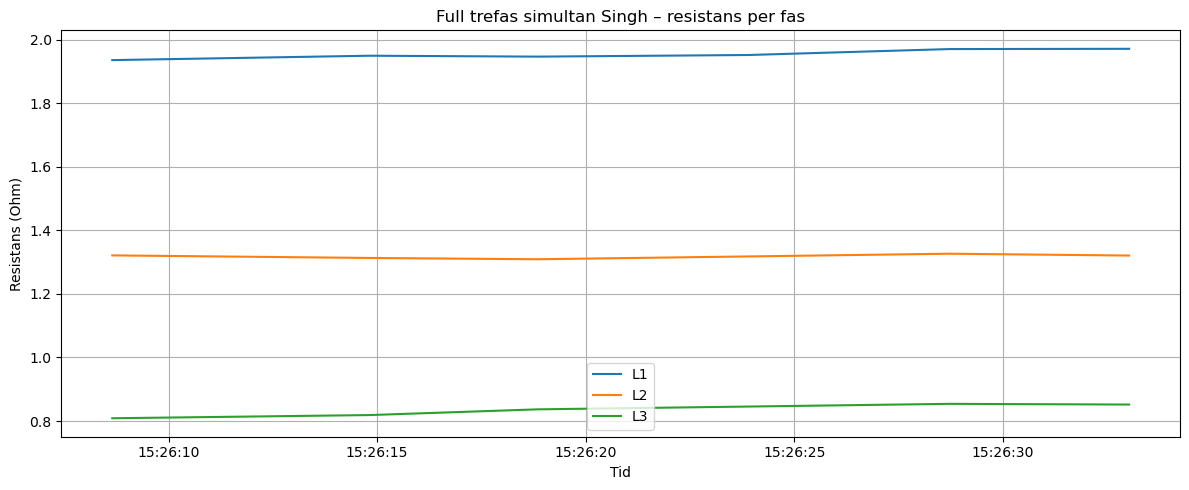

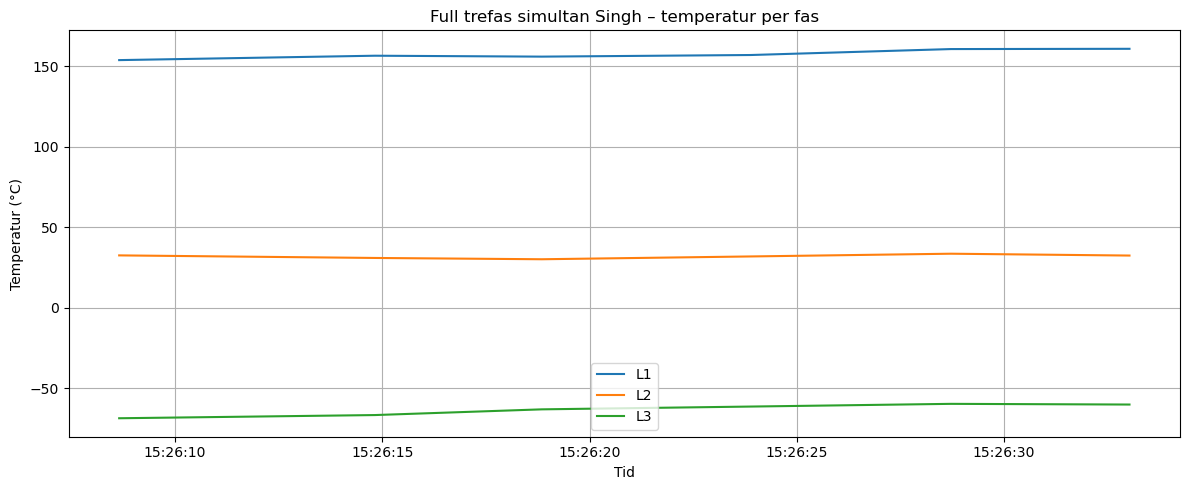

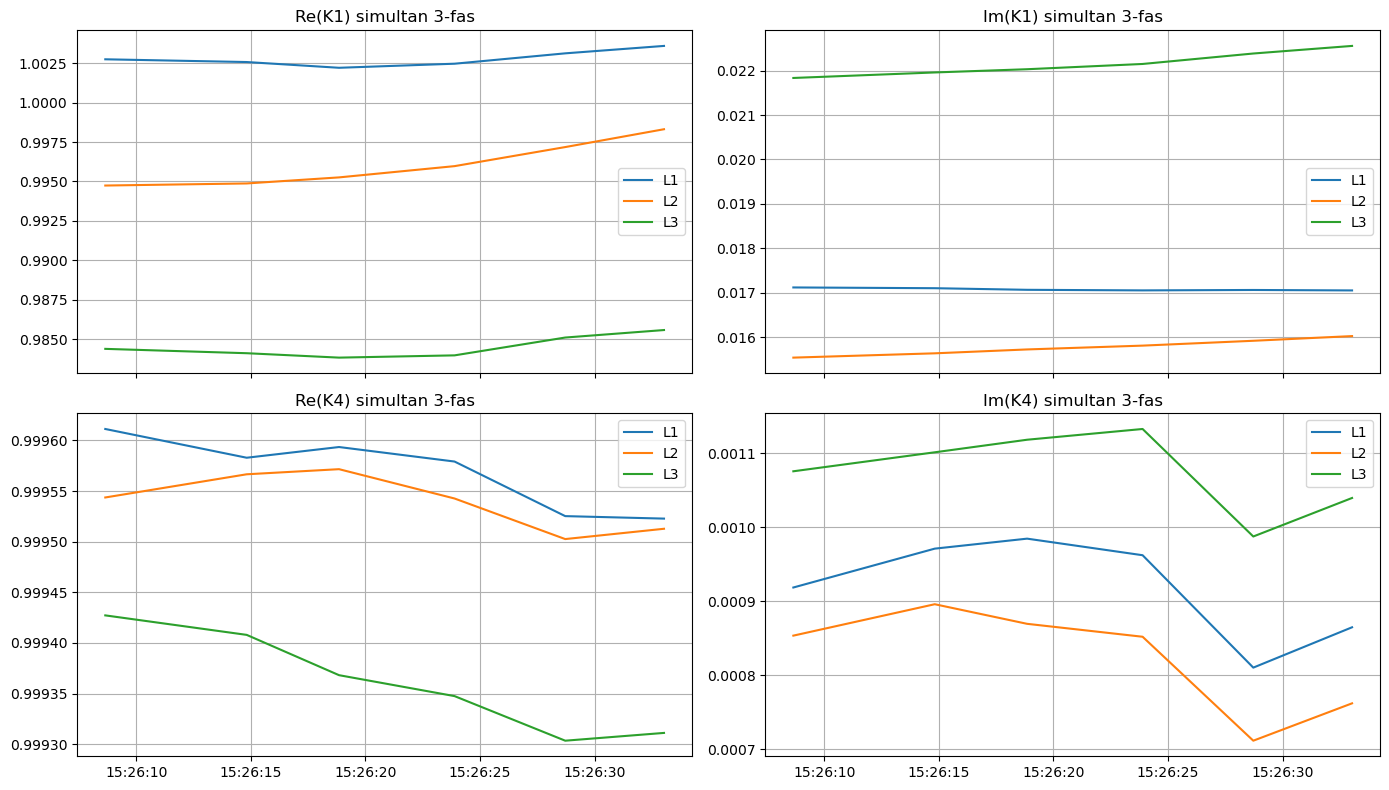

JÄMFÖRELSE MOT R_ref_test:


,Phase,R_mean_Ohm,R_ref_test_Ohm,Absolute_error_Ohm,Relative_error_percent
0,L1,1.953719,1.98,-0.026281,-1.327327
1,L2,1.317836,1.98,-0.662164,-33.442617
2,L3,0.835901,1.98,-1.144099,-57.782756


Sparat till: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\singh_3ph_simultaneous.xlsx

TAIL out_3ph_filtered:


,Timestamp,K1_real_L1,K1_real_L2,K1_real_L3,K1_imag_L1,K1_imag_L2,K1_imag_L3,K4_real_L1,K4_real_L2,K4_real_L3,K4_imag_L1,K4_imag_L2,K4_imag_L3,B_S_L1,B_S_L2,B_S_L3,R_Ohm_L1,R_Ohm_L2,R_Ohm_L3,X_Ohm_L1,X_Ohm_L2,X_Ohm_L3,u_R_Ohm_L1,u_R_Ohm_L2,u_R_Ohm_L3,u_X_Ohm_L1,u_X_Ohm_L2,u_X_Ohm_L3,T_C_L1,T_C_L2,T_C_L3,u_T_C_L1,u_T_C_L2,u_T_C_L3
2,2025-12-11 15:26:14.820000,1.002568,0.994874,0.984116,0.017104,0.015638,0.021959,0.999583,0.999567,0.999408,0.000971,0.000896,0.001101,0.000016,0.000036,0.000065,1.949024,1.312897,0.818731,6.351893,5.930674,6.324321,0.010356,0.010258,0.010415,0.010356,0.010258,0.010415,156.456582,30.931258,-66.581032,2.043521,2.024107,2.055110
3,2025-12-11 15:26:18.849999,1.002204,0.995258,0.983837,0.017067,0.015725,0.022031,0.999594,0.999572,0.999368,0.000985,0.000870,0.001118,0.000016,0.000035,0.000065,1.946158,1.308810,0.836694,6.346066,5.941635,6.319344,0.010121,0.010020,0.010181,0.010121,0.010020,0.010181,155.891030,30.124836,-63.036403,1.997210,1.977192,2.008912
4,2025-12-11 15:26:23.889999,1.002462,0.995971,0.983980,0.017054,0.015811,0.022150,0.999579,0.999543,0.999348,0.000962,0.000852,0.001133,0.000016,0.000033,0.000065,1.951236,1.317636,0.845472,6.354672,5.948619,6.313060,0.009642,0.009525,0.009698,0.009642,0.009525,0.009698,156.893062,31.866377,-61.304334,1.902540,1.879584,1.913644
5,2025-12-11 15:26:28.719999,1.003119,0.997179,0.985109,0.017064,0.015920,0.022385,0.999525,0.999503,0.999304,0.000810,0.000712,0.000988,0.000014,0.000030,0.000062,1.969930,1.326243,0.853997,6.419866,6.006481,6.375837,0.009017,0.008890,0.009057,0.009017,0.008890,0.009057,160.581772,33.564870,-59.622100,1.779306,1.754230,1.787260
6,2025-12-11 15:26:33.029999,1.003589,0.998310,0.985584,0.017053,0.016026,0.022556,0.999523,0.999513,0.999311,0.000865,0.000762,0.001040,0.000013,0.000027,0.000061,1.970761,1.320453,0.851815,6.396250,5.985582,6.352600,0.008310,0.008187,0.008359,0.008310,0.008187,0.008359,160.745717,32.422322,-60.052636,1.639741,1.615592,1.649538


In [6]:
# ============================================================
# PLOTTAR
# ============================================================

plt.figure(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    plt.plot(out_3ph_filtered["Timestamp"], out_3ph_filtered[f"R_Ohm_{ph}"], label=ph)
plt.title("Full trefas simultan Singh – resistans per fas")
plt.xlabel("Tid")
plt.ylabel("Resistans (Ohm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    plt.plot(out_3ph_filtered["Timestamp"], out_3ph_filtered[f"T_C_{ph}"], label=ph)
plt.title("Full trefas simultan Singh – temperatur per fas")
plt.xlabel("Tid")
plt.ylabel("Temperatur (°C)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ph in ["L1", "L2", "L3"]:
    axes[0, 0].plot(out_3ph_filtered["Timestamp"], out_3ph_filtered[f"K1_real_{ph}"], label=ph)
    axes[0, 1].plot(out_3ph_filtered["Timestamp"], out_3ph_filtered[f"K1_imag_{ph}"], label=ph)
    axes[1, 0].plot(out_3ph_filtered["Timestamp"], out_3ph_filtered[f"K4_real_{ph}"], label=ph)
    axes[1, 1].plot(out_3ph_filtered["Timestamp"], out_3ph_filtered[f"K4_imag_{ph}"], label=ph)

axes[0, 0].set_title("Re(K1) simultan 3-fas")
axes[0, 1].set_title("Im(K1) simultan 3-fas")
axes[1, 0].set_title("Re(K4) simultan 3-fas")
axes[1, 1].set_title("Im(K4) simultan 3-fas")

for ax in axes.ravel():
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

# ============================================================
# JÄMFÖRELSE MOT TEST-REFERENS
# ============================================================

R_ref_test = 1.98

comparison_3ph_rows = []

for ph in ["L1", "L2", "L3"]:
    R_mean = out_3ph_filtered[f"R_Ohm_{ph}"].mean()
    abs_err = R_mean - R_ref_test
    rel_err_pct = 100 * abs_err / R_ref_test

    comparison_3ph_rows.append({
        "Phase": ph,
        "R_mean_Ohm": R_mean,
        "R_ref_test_Ohm": R_ref_test,
        "Absolute_error_Ohm": abs_err,
        "Relative_error_percent": rel_err_pct
    })

comparison_3ph_df = pd.DataFrame(comparison_3ph_rows)

print("JÄMFÖRELSE MOT R_ref_test:")
display(comparison_3ph_df)

# ============================================================
# SPARA TILL EXCEL
# ============================================================

output_file = r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\singh_3ph_simultaneous.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    out_3ph.to_excel(writer, sheet_name="Results_3ph", index=False)
    out_3ph_filtered.to_excel(writer, sheet_name="Results_3ph_filtered", index=False)
    summary_3ph_df.to_excel(writer, sheet_name="Summary_3ph", index=False)
    comparison_3ph_df.to_excel(writer, sheet_name="Compare_Rref", index=False)
    results_3ph_long.to_excel(writer, sheet_name="LongFormat", index=False)

print("Sparat till:", output_file)

print("\nTAIL out_3ph_filtered:")
display(out_3ph_filtered.tail())


,count,mean,std,min,25%,50%,75%,max
ΔU_L1_abs,7669.0,3.868850e+02,5.796900e+00,3.701562e+02,3.832500e+02,3.867031e+02,3.899766e+02,4.146641e+02
ΔU_L1_pct,7669.0,4.806000e-01,7.300000e-03,4.594000e-01,4.761000e-01,4.804000e-01,4.845000e-01,5.153000e-01
ΔI_L1_abs,7669.0,1.770600e+00,1.578000e-01,1.077100e+00,1.664400e+00,1.771800e+00,1.878300e+00,2.350500e+00
ΔI_L1_pct,7669.0,9.347000e-01,8.370000e-02,5.844000e-01,8.782000e-01,9.340000e-01,9.907000e-01,1.255600e+00
ΔU_L1_deg,7669.0,8.988000e-01,3.710000e-02,8.143000e-01,8.682000e-01,9.038000e-01,9.266000e-01,9.934000e-01
ΔI_L1_deg,7669.0,-1.790156e+02,4.800000e-02,-1.792241e+02,-1.790482e+02,-1.790158e+02,-1.789828e+02,-1.788376e+02
ΔU_L2_abs,7669.0,3.174279e+02,4.890100e+00,3.015547e+02,3.140859e+02,3.169297e+02,3.204922e+02,3.391328e+02
ΔU_L2_pct,7669.0,3.940000e-01,6.100000e-03,3.744000e-01,3.898000e-01,3.934000e-01,3.978000e-01,4.215000e-01
ΔI_L2_abs,7669.0,1.909000e+00,1.645000e-01,1.331100e+00,1.797400e+00,1.910900e+00,2.018500e+00,2.519300e+00
ΔI_L2_pct,7669.0,9.555000e-01,8.200000e-02,6.777000e-01,9.009000e-01,9.543000e-01,1.010300e+00,1.259300e+00


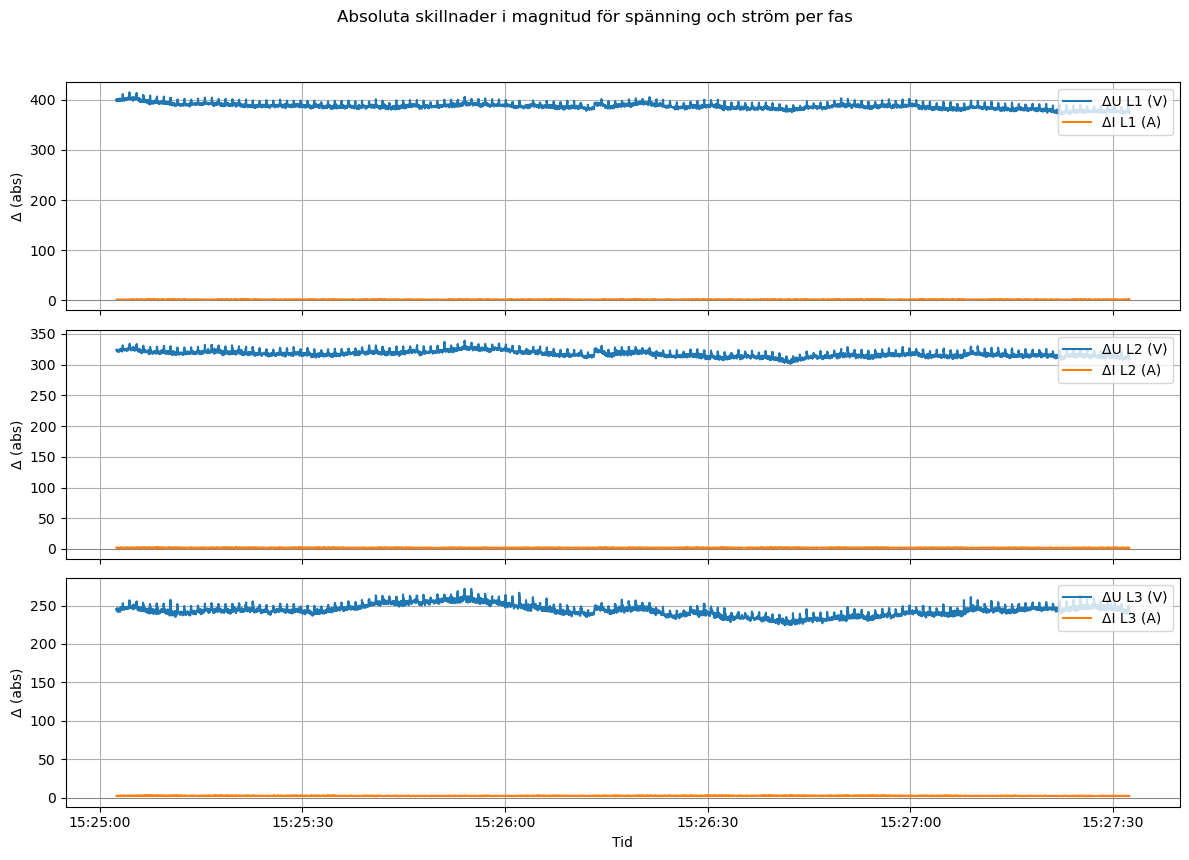

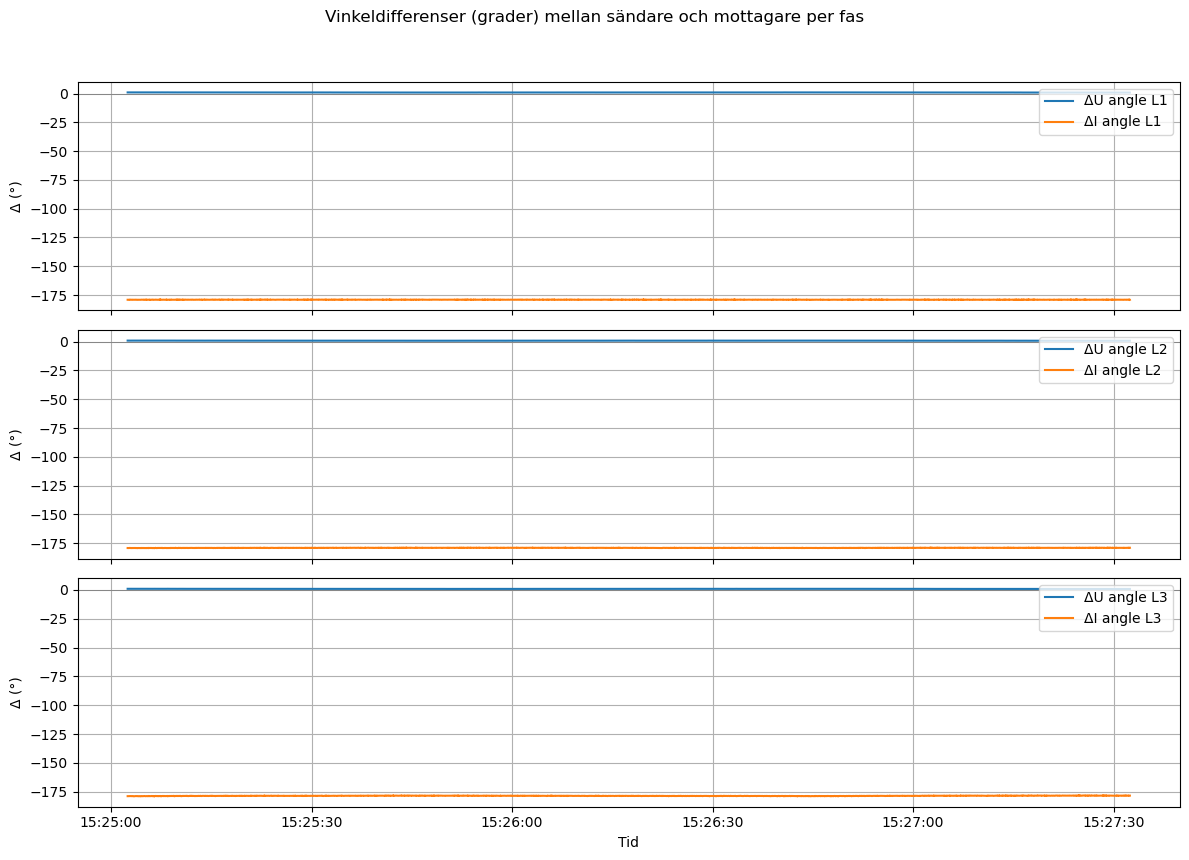

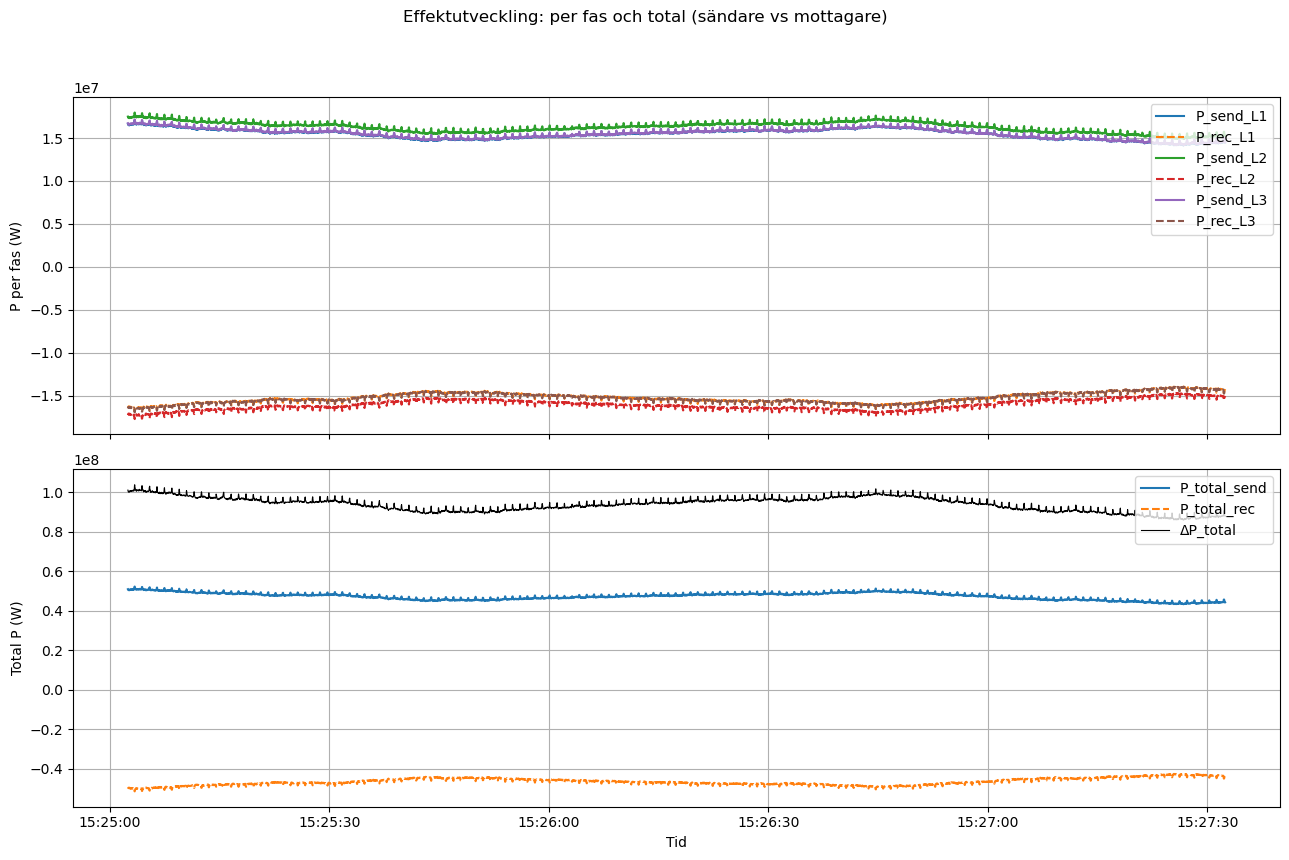

C:\Users\lundi\AppData\Local\Temp\ipykernel_219656\1805593137.py:152: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[1].boxplot([diff_df[f"ΔU_{ph}_abs"].dropna() for ph in phases], labels=phases); axs[1].set_title("Boxplot ΔU per fas (V)")
C:\Users\lundi\AppData\Local\Temp\ipykernel_219656\1805593137.py:154: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[3].boxplot([diff_df[f"ΔI_{ph}_abs"].dropna() for ph in phases], labels=phases); axs[3].set_title("Boxplot ΔI per fas (A)")


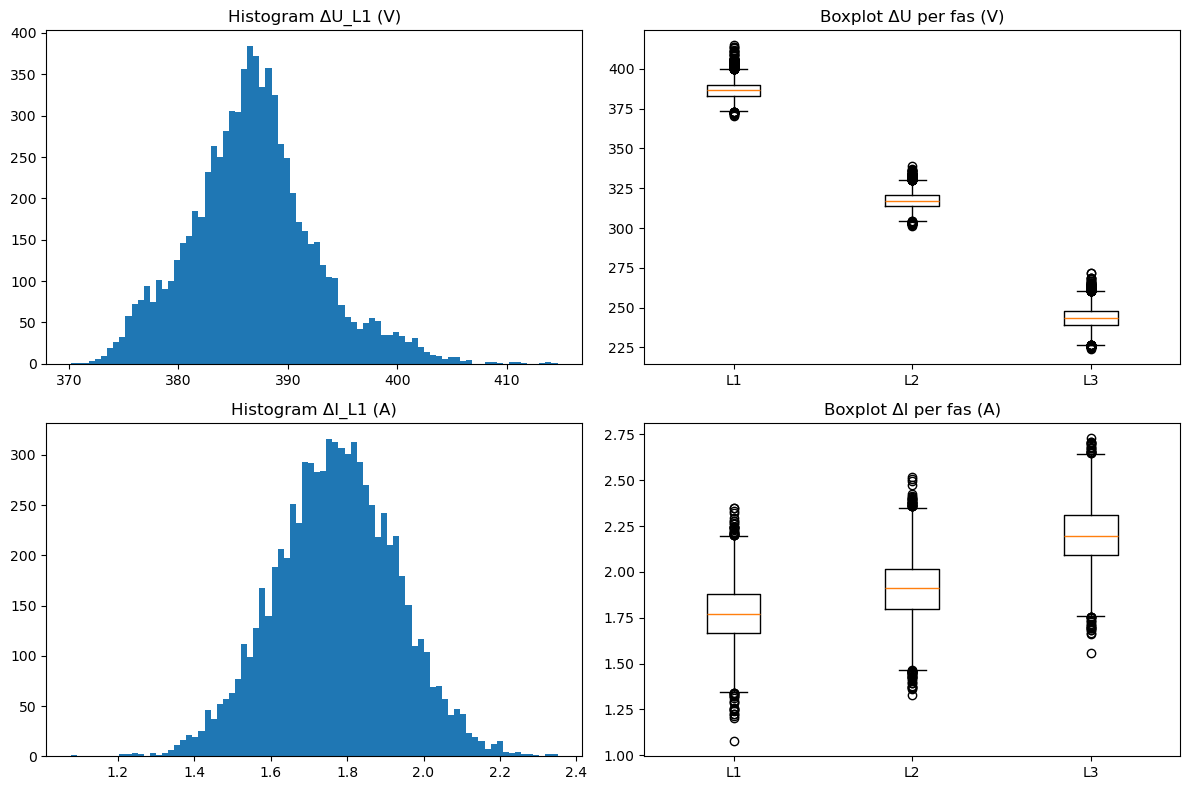

Klar — plots skapade och diff_df finns i minnet.


In [7]:
# ---- Ny cell: Plotta skillnader mellan send och rec ----
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Hjälpfunktioner
def wrap_angle_deg(angle_deg):
    """Wrap angles to [-180, 180] grader (array-kompatibel)."""
    a = (angle_deg + 180) % 360 - 180
    return a

def ensure_numeric_and_clean(df, cols):
    """Säkerställ numeriska kolumner; konvertera komma->punkt och to_numeric."""
    for c in cols:
        if c in df.columns:
            df[c] = df[c].astype(str).str.replace(",", ".", regex=False)
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def build_phasor(mag, ang_deg):
    """Bygg komplex phasor från magnitud (RMS) och vinkel (grader)."""
    return mag * np.exp(1j * np.deg2rad(ang_deg))

# ---- Kontrollera att df_clean finns ----
try:
    df_clean
except NameError:
    raise RuntimeError("df_clean finns inte i minnet. Kör cellerna som skapar df_clean först.")

# ---- Ange faser och förväntade kolumner ----
phases = ["L1", "L2", "L3"]
cols_expected = []
for ph in phases:
    cols_expected += [
        f"U{ph}MAG_S", f"U{ph}ANG_S", f"U{ph}MAG_R", f"U{ph}ANG_R",
        f"I{ph}MAG_S", f"I{ph}ANG_S", f"I{ph}MAG_R", f"I{ph}ANG_R",
    ]

missing = [c for c in cols_expected if c not in df_clean.columns]
if missing:
    raise ValueError(f"Saknade kolumner i df_clean: {missing}")

# Kopiera och sanitera
df = df_clean.copy()
df = ensure_numeric_and_clean(df, cols_expected)

# Bygg diff_df med skillnader och effekt
diff_df = pd.DataFrame(index=df.index)

for ph in phases:
    # Läs kolumner
    U_s_mag = df[f"U{ph}MAG_S"]
    U_s_ang = df[f"U{ph}ANG_S"]
    U_r_mag = df[f"U{ph}MAG_R"]
    U_r_ang = df[f"U{ph}ANG_R"]

    I_s_mag = df[f"I{ph}MAG_S"]
    I_s_ang = df[f"I{ph}ANG_S"]
    I_r_mag = df[f"I{ph}MAG_R"]
    I_r_ang = df[f"I{ph}ANG_R"]

    # Absolut- och procentskillnader
    diff_df[f"ΔU_{ph}_abs"] = U_s_mag - U_r_mag
    diff_df[f"ΔU_{ph}_pct"] = 100.0 * diff_df[f"ΔU_{ph}_abs"] / U_r_mag.replace({0: np.nan})

    diff_df[f"ΔI_{ph}_abs"] = I_s_mag - I_r_mag
    diff_df[f"ΔI_{ph}_pct"] = 100.0 * diff_df[f"ΔI_{ph}_abs"] / I_r_mag.replace({0: np.nan})

    # Vinkeldifferens (grader), omslaget görs så skillnaden hamnar i [-180,180]
    ang_diff_U = wrap_angle_deg(U_s_ang - U_r_ang)
    ang_diff_I = wrap_angle_deg(I_s_ang - I_r_ang)
    diff_df[f"ΔU_{ph}_deg"] = ang_diff_U
    diff_df[f"ΔI_{ph}_deg"] = ang_diff_I

    # Bygg phasors
    Vs = build_phasor(U_s_mag, U_s_ang)
    Vr = build_phasor(U_r_mag, U_r_ang)
    Is_ = build_phasor(I_s_mag, I_s_ang)
    Ir = build_phasor(I_r_mag, I_r_ang)

    # Om du använder samma konvention som i tidigare cell (inverterad mottagarström),
    # avkommentera nästa rad:
    # Ir = -Ir

    # Per-fas aktiv effekt (P = Re(V * conj(I)))
    diff_df[f"P_send_{ph}"] = np.real(Vs * np.conj(Is_))
    diff_df[f"P_rec_{ph}"]  = np.real(Vr * np.conj(Ir))

# Total aktiv effekt (summa av faser)
diff_df["P_total_send"] = diff_df[[f"P_send_{ph}" for ph in phases]].sum(axis=1)
diff_df["P_total_rec"]  = diff_df[[f"P_rec_{ph}" for ph in phases]].sum(axis=1)
diff_df["ΔP_total"] = diff_df["P_total_send"] - diff_df["P_total_rec"]

# Enkel sammanfattande statistik
display(diff_df[[c for c in diff_df.columns if (c.startswith("ΔU") or c.startswith("ΔI") or c.startswith("ΔP"))]].describe().T.round(4))

# ---- Plotta: magnitudskillnader (ΔU och ΔI) ----
plt.rcParams.update({"figure.figsize": (12, 9)})
fig, axs = plt.subplots(3, 1, sharex=True)
for i, ph in enumerate(phases):
    axs[i].plot(diff_df.index, diff_df[f"ΔU_{ph}_abs"], label=f"ΔU {ph} (V)")
    axs[i].plot(diff_df.index, diff_df[f"ΔI_{ph}_abs"], label=f"ΔI {ph} (A)")
    axs[i].axhline(0, color="gray", linewidth=0.6)
    axs[i].set_ylabel("Δ (abs)")
    axs[i].legend(loc="upper right")
    axs[i].grid(True)
axs[-1].set_xlabel("Tid")
plt.suptitle("Absoluta skillnader i magnitud för spänning och ström per fas")
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()

# ---- Plotta: vinkeldifferenser (grader) ----
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(12, 9))
for i, ph in enumerate(phases):
    axs[i].plot(diff_df.index, diff_df[f"ΔU_{ph}_deg"], label=f"ΔU angle {ph}")
    axs[i].plot(diff_df.index, diff_df[f"ΔI_{ph}_deg"], label=f"ΔI angle {ph}")
    axs[i].axhline(0, color="gray", linewidth=0.6)
    axs[i].set_ylabel("Δ (°)")
    axs[i].legend(loc="upper right")
    axs[i].grid(True)
axs[-1].set_xlabel("Tid")
plt.suptitle("Vinkeldifferenser (grader) mellan sändare och mottagare per fas")
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()

# ---- Plotta: effekt per fas och total ----
fig, ax = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
for ph in phases:
    ax[0].plot(diff_df.index, diff_df[f"P_send_{ph}"], label=f"P_send_{ph}")
    ax[0].plot(diff_df.index, diff_df[f"P_rec_{ph}"], linestyle="--", label=f"P_rec_{ph}")
ax[0].legend(loc="upper right")
ax[0].set_ylabel("P per fas (W)")
ax[0].grid(True)

ax[1].plot(diff_df.index, diff_df["P_total_send"], label="P_total_send")
ax[1].plot(diff_df.index, diff_df["P_total_rec"], label="P_total_rec", linestyle="--")
ax[1].plot(diff_df.index, diff_df["ΔP_total"], label="ΔP_total", color="black", linewidth=0.8)
ax[1].legend(loc="upper right")
ax[1].set_ylabel("Total P (W)")
ax[1].set_xlabel("Tid")
ax[1].grid(True)

plt.suptitle("Effektutveckling: per fas och total (sändare vs mottagare)")
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()

# ---- Histogram / boxplot av skillnader (exempel) ----
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.ravel()
axs[0].hist(diff_df["ΔU_L1_abs"].dropna(), bins=80); axs[0].set_title("Histogram ΔU_L1 (V)")
axs[1].boxplot([diff_df[f"ΔU_{ph}_abs"].dropna() for ph in phases], labels=phases); axs[1].set_title("Boxplot ΔU per fas (V)")
axs[2].hist(diff_df["ΔI_L1_abs"].dropna(), bins=80); axs[2].set_title("Histogram ΔI_L1 (A)")
axs[3].boxplot([diff_df[f"ΔI_{ph}_abs"].dropna() for ph in phases], labels=phases); axs[3].set_title("Boxplot ΔI per fas (A)")
plt.tight_layout()
plt.show()

# ---- Valfritt: spara diff_df ----
# diff_df.to_excel("diffs_send_rec.xlsx")
print("Klar — plots skapade och diff_df finns i minnet.")

In [8]:
# ---- Synka send & rec robustt ----
%matplotlib inline
import pandas as pd
import numpy as np

# Antag: du har redan läst in send och rec DataFrames med kolumn "Timestamp"
# Om inte: ladda dem här (exempel):
# send = pd.read_excel("send.xlsx")
# rec  = pd.read_excel("rec.xlsx")

# 0) backup (valfritt men rekommenderat)
send_orig = send.copy()
rec_orig  = rec.copy()

# 1) konvertera Timestamp till datetime och dropna
for df, name in [(send, "send"), (rec, "rec")]:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    n_before = len(df)
    df.dropna(subset=['Timestamp'], inplace=True)
    print(f"{name}: rader före={n_before}, efter dropna Timestamp={len(df)}")

# 2) räkna unika tidstämplar och dubbletter
print("\nUnika timestamps / dubbletter:")
for df, name in [(send, "send"), (rec, "rec")]:
    uniq = df['Timestamp'].nunique()
    total = len(df)
    dups = total - uniq
    print(f"{name}: total={total}, unika={uniq}, dubbletter={dups}")
    if dups>0:
        print("Exempel dubbletter (Timestamp, count):")
        print(df['Timestamp'].value_counts().head(5))

# 3) (valfritt) om du bestämmer dig för att ta bort dubbla timestamps, välj policy:
#    - keep='first' eller keep='last' eller aggregate (t.ex. mean)
# Exempel: ta första raden per Timestamp för att göra index unikt:
send_nd = send.drop_duplicates(subset=['Timestamp'], keep='first').copy()
rec_nd  = rec.drop_duplicates(subset=['Timestamp'], keep='first').copy()
print("\nEfter drop_duplicates (first): send_nd:", len(send_nd), " rec_nd:", len(rec_nd))

# 4) Runda timestamps till en rimlig upplösning (t.ex. 1s eller 100ms) om lämpligt
#    Justera 'round_to' till '1s', '100ms', '10ms' beroende på dina data
round_to = '1s'   # <- byt vid behov
send_nd['Timestamp_round'] = send_nd['Timestamp'].dt.round(round_to)
rec_nd['Timestamp_round']  = rec_nd['Timestamp'].dt.round(round_to)
print("\nExempel rundade timestamps (första 5):")
display(send_nd[['Timestamp','Timestamp_round']].head())
display(rec_nd[['Timestamp','Timestamp_round']].head())

# 5) Sortera på Timestamp (krav för merge_asof)
send_sorted = send_nd.sort_values('Timestamp_round').reset_index(drop=True)
rec_sorted  = rec_nd.sort_values('Timestamp_round').reset_index(drop=True)

# 6) Använd merge_asof för att matcha närmaste tidsstämpel med tolerans
#    Välj tolerance beroende på din datakvalitet (ex '0.5s', '1s', '2s')
tolerance = pd.Timedelta("1s")   # <- byt vid behov
merged = pd.merge_asof(
    send_sorted, rec_sorted,
    left_on='Timestamp_round', right_on='Timestamp_round',
    direction='nearest',
    tolerance=tolerance,
    suffixes=('_S','_R')
)

# 7) Statistik: hur många fick en match (rec-kolumn ej NaN) 
#    Anta att rec har kolumn 'ID' eller annan obligatorisk kolumn; välj en kolumn som indikerar match
rec_indicator_col = None
for c in rec_sorted.columns:
    if c not in send_sorted.columns and c != 'Timestamp_round':
        rec_indicator_col = c
        break
# Fallback: använd 'Timestamp' från rec (Timestamp_R)
if rec_indicator_col is None:
    rec_indicator_col = 'Timestamp_R'  # merge_asof kommer skapa Timestamp_R om names korsar

matched = merged[merged[[col for col in merged.columns if col.endswith('_R')]].notna().any(axis=1)]
num_matched = len(matched)
total_send = len(send_sorted)
print(f"\nMatched (within {tolerance}) = {num_matched} / {total_send} send-rader ({100*num_matched/total_send:.1f}%)")

# 8) Visa exempel på icke-matcherade (nära/ej nära)
unmatched = merged[merged[[col for col in merged.columns if col.endswith('_R')]].isna().all(axis=1)]
print("Exempel icke-matcherade (första 10):")
display(unmatched[['Timestamp_round','Timestamp_S']].head(10))

# 9) Skapa slutlig df_synced: välj strategi
#    A) Keep only matched:
df_synced = matched.copy()
#    B) Om du hellre vill behålla ALLA och fylla saknat med NaN, använd merged som är outer-like

print("\ndf_synced klar. Kolumnexempel:", list(df_synced.columns)[:10])
# Spara om du vill:
# df_synced.to_excel("merged_send_rec_synced.xlsx", index=False)

send: rader före=180000, efter dropna Timestamp=180000
rec: rader före=180000, efter dropna Timestamp=180000

Unika timestamps / dubbletter:
send: total=180000, unika=15000, dubbletter=165000
Exempel dubbletter (Timestamp, count):
Timestamp
2025-12-11 15:25:02.469999    12
2025-12-11 15:26:42.509999    12
2025-12-11 15:26:42.389999    12
2025-12-11 15:26:42.399999    12
2025-12-11 15:26:42.409999    12
Name: count, dtype: int64
rec: total=180000, unika=15000, dubbletter=165000
Exempel dubbletter (Timestamp, count):
Timestamp
2025-12-11 15:25:02.469999    12
2025-12-11 15:26:42.509999    12
2025-12-11 15:26:42.389999    12
2025-12-11 15:26:42.399999    12
2025-12-11 15:26:42.410000    12
Name: count, dtype: int64

Efter drop_duplicates (first): send_nd: 15000  rec_nd: 15000

Exempel rundade timestamps (första 5):


,Timestamp,Timestamp_round
0,2025-12-11 15:25:02.469999,2025-12-11 15:25:02
12,2025-12-11 15:25:02.480001,2025-12-11 15:25:02
24,2025-12-11 15:25:02.490000,2025-12-11 15:25:02
36,2025-12-11 15:25:02.499999,2025-12-11 15:25:02
48,2025-12-11 15:25:02.509999,2025-12-11 15:25:03


,Timestamp,Timestamp_round
0,2025-12-11 15:25:02.469999,2025-12-11 15:25:02
12,2025-12-11 15:25:02.479999,2025-12-11 15:25:02
24,2025-12-11 15:25:02.489999,2025-12-11 15:25:02
36,2025-12-11 15:25:02.499999,2025-12-11 15:25:02
48,2025-12-11 15:25:02.509999,2025-12-11 15:25:03



Matched (within 0 days 00:00:01) = 15000 / 15000 send-rader (100.0%)
Exempel icke-matcherade (första 10):


,Timestamp_round,Timestamp_S



df_synced klar. Kolumnexempel: ['Timestamp_S', 'ID_S', 'Value_S', 'Parameter_S', 'Timestamp_round', 'Timestamp_R', 'ID_R', 'Value_R', 'Parameter_R']


In [9]:
print("Bohus R_ref =", 0.0729 * 17.25)
print("Gota  R_ref =", 0.0348 * 21.95)

for ph in ["L1", "L2", "L3"]:
    print(ph, out_3ph_filtered[f"R_Ohm_{ph}"].mean())

Bohus R_ref = 1.257525
Gota  R_ref = 0.7638599999999999
L1 1.953718934396668
L2 1.3178361854400829
L3 0.8359014233373424


In [10]:
print("=== Medelvärden per fas ===")
for ph in ["L1", "L2", "L3"]:
    print(
        ph,
        "R_mean =", out_3ph_filtered[f"R_Ohm_{ph}"].mean(),
        "R_std =", out_3ph_filtered[f"R_Ohm_{ph}"].std(),
        "X_mean =", out_3ph_filtered[f"X_Ohm_{ph}"].mean(),
        "u_R_mean =", out_3ph_filtered[f"u_R_Ohm_{ph}"].mean()
    )

print("\n=== Bohus/Gota referenser ===")
print("Bohus R_ref =", 0.0729 * 17.25)
print("Gota  R_ref =", 0.0348 * 21.95)

=== Medelvärden per fas ===
L1 R_mean = 1.953718934396668 R_std = 0.01400980287679713 X_mean = 6.374084480485205 u_R_mean = 0.009638480476263209
L2 R_mean = 1.3178361854400829 R_std = 0.006217946695869098 X_mean = 5.960491861211849 u_R_mean = 0.00953236823550717
L3 R_mean = 0.8359014233373424 R_std = 0.018480982417139597 X_mean = 6.336911447413478 u_R_mean = 0.009686865906301596

=== Bohus/Gota referenser ===
Bohus R_ref = 1.257525
Gota  R_ref = 0.7638599999999999


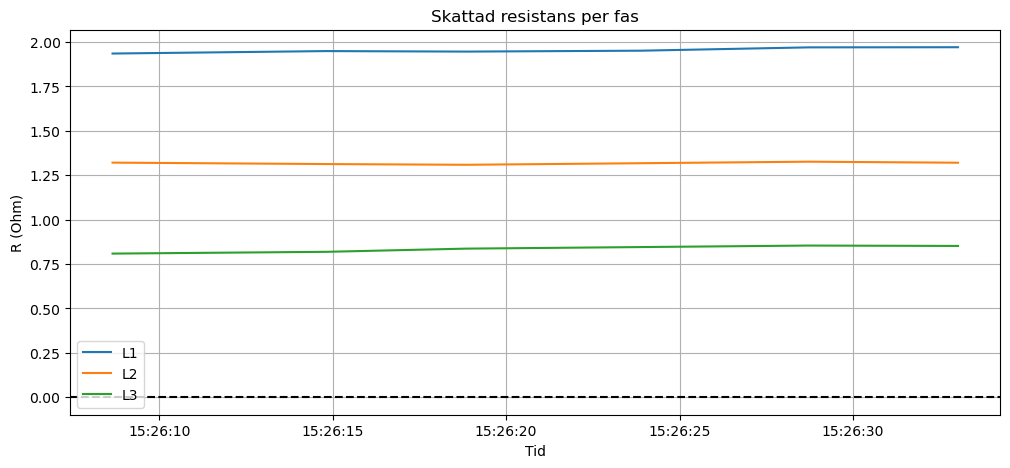

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
for ph in ["L1","L2","L3"]:
    plt.plot(out_3ph_filtered["Timestamp"], out_3ph_filtered[f"R_Ohm_{ph}"], label=ph)
plt.axhline(0, color="black", linestyle="--")
plt.title("Skattad resistans per fas")
plt.ylabel("R (Ohm)")
plt.xlabel("Tid")
plt.grid(True)
plt.legend()
plt.show()

In [12]:
def wrap_angle_deg(a):
    return (a + 180) % 360 - 180

for ph in ["L1", "L2", "L3"]:
    I_r_ang_corr = wrap_angle_deg(df_clean[f"I{ph}ANG_R"] + 180.0)
    dI_corr = wrap_angle_deg(df_clean[f"I{ph}ANG_S"] - I_r_ang_corr)
    dU = wrap_angle_deg(df_clean[f"U{ph}ANG_S"] - df_clean[f"U{ph}ANG_R"])

    print(ph, "mean ΔU =", dU.mean(), "mean ΔI_corr =", dI_corr.mean())

L1 mean ΔU = 0.8987697766549686 mean ΔI_corr = 0.9844170869472725
L2 mean ΔU = 0.8759890024848692 mean ΔI_corr = 0.9545636475791154
L3 mean ΔU = 0.8987592451512287 mean ΔI_corr = 1.4597826978781854


## T8_Singh_diagnostics – diagnostik av fasvisa skillnader i Singh-resultat

Denna del läggs efter den ursprungliga T7-körningen. Syftet är att undersöka varför Singh-metoden kan ge stora nivåskillnader i skattad resistans mellan L1, L2 och L3.

Diagnostiken testar:

1. alternativ fasmappning mellan sändar- och mottagarstation,
2. mottagarströmmens teckenkonvention, både globalt och per fas,
3. enkla vinkel- och magnitudmatriser för fasparning,
4. signalvariation under mätperioden,
5. konditionstal för Singh-minstakvadratmatriser,
6. om små fasvisa vinkeloffsetar i mottagarspänningen kan flytta den skattade resistansen mycket.

Denna del ersätter inte huvudresultatet från T7. Den används som diagnostik och som underlag till diskussionen om systematiska fasvisa fel, fasmappning, strömriktning och identifierbarhet.


T8 output-mapp: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\T8_Singh_diagnostics
Antal rader i df_for_test: 7669
Start: 2025-12-11 15:25:02.469999
Slut : 2025-12-11 15:27:32.450000

Kör TEST 1: fasmappning och global strömriktning...

Bästa fasmappningar och global strömriktning


,label,map_L1,map_L2,map_L3,current_case,R_phase_spread_Ohm,R_cv_percent,R_mean_abs_error_vs_ref,X_mean_abs_error_vs_ref,negative_R_count,score
0,"L1->L1, L2->L2, L3->L3, Ir_inverted_all",L1,L2,L3,Ir_inverted_all,1.004154,26.794462,0.422549,0.168376,0,1.426703
8,"L1->L3, L2->L1, L3->L2, Ir_inverted_all",L3,L1,L2,Ir_inverted_all,3.521204,29.227325,3.679317,11.157311,0,7.200521
7,"L1->L2, L2->L3, L3->L1, Ir_raw_all",L2,L3,L1,Ir_raw_all,3.612659,22.858333,5.207038,4.619078,0,8.819696
2,"L1->L1, L2->L3, L3->L2, Ir_inverted_all",L1,L3,L2,Ir_inverted_all,9.423650,1045.079970,3.400984,7.618693,2,212.824634
4,"L1->L2, L2->L1, L3->L3, Ir_inverted_all",L2,L1,L3,Ir_inverted_all,11.332217,475.440849,3.852356,6.582470,2,215.184573
10,"L1->L3, L2->L2, L3->L1, Ir_inverted_all",L3,L2,L1,Ir_inverted_all,13.448197,1002.303277,4.570564,5.615446,2,218.018761
3,"L1->L1, L2->L3, L3->L2, Ir_raw_all",L1,L3,L2,Ir_raw_all,9.423650,1045.079970,4.239318,5.596264,4,413.662968
5,"L1->L2, L2->L1, L3->L3, Ir_raw_all",L2,L1,L3,Ir_raw_all,11.332217,475.440849,4.540789,6.571743,4,415.873006
11,"L1->L3, L2->L2, L3->L1, Ir_raw_all",L3,L2,L1,Ir_raw_all,13.448197,1002.303277,5.408897,7.494554,4,418.857094
1,"L1->L1, L2->L2, L3->L3, Ir_raw_all",L1,L2,L3,Ir_raw_all,1.004154,26.794462,2.787649,13.090794,6,603.791802



Bästa fasmappning enligt enkel score:
{'L1': 'L1', 'L2': 'L2', 'L3': 'L3'}
Bästa globalt strömtecken: Ir_inverted_all

Kör TEST 2: per-fas strömtecken för bästa fasmappning...

Per-fas strömtecken


,signs,R_phase_spread_Ohm,R_cv_percent,R_mean_abs_error_vs_ref,X_mean_abs_error_vs_ref,negative_R_count,score
0,L1:-1_L2:-1_L3:-1,1.004154,26.794462,0.422549,0.168376,0,1.426703
1,L1:-1_L2:-1_L3:1,3.069452,159.436292,1.110982,4.538376,2,204.180434
2,L1:-1_L2:1_L3:-1,3.557797,290.161650,1.260883,4.350794,2,204.818680
4,L1:1_L2:-1_L3:-1,3.557797,914.051427,1.260883,4.538376,2,204.818680
6,L1:1_L2:1_L3:-1,3.069452,159.436292,2.099216,8.720794,4,405.168668
3,L1:-1_L2:1_L3:1,3.557797,914.051427,1.949315,8.720794,4,405.507113
5,L1:1_L2:-1_L3:1,3.557797,290.161650,1.949315,8.908376,4,405.507113
7,L1:1_L2:1_L3:1,1.004154,26.794462,2.787649,13.090794,6,603.791802



Bästa per-fas strömtecken enligt enkel score:
{'L1': -1, 'L2': -1, 'L3': -1}

Kör TEST 3: fasparningsmatriser...

U_angle_mean_deg


...

,Phase,R_mean_Ohm,R_std_Ohm,X_mean_Ohm,X_std_Ohm,T_mean_C,T_std_C
0,L1,1.950655,0.015142,6.379384,0.030067,156.778308,2.987942
1,L2,1.320039,0.008136,5.965349,0.029529,32.340657,1.605370
2,L3,0.833633,0.017906,6.341989,0.025432,-63.640450,3.533403



Mått för bästa Singh-variant


,label,R_min_mean,R_max_mean,R_phase_spread_Ohm,R_cv_percent,R_mean_abs_error_vs_ref,X_mean_abs_error_vs_ref,negative_R_count,score
0,best_case,0.833633,1.950655,1.117022,33.424763,0.393187,0.326093,0,1.510209



Kör TEST 5: fasvisa mottagarspännings-vinkeloffsetar...

Vinkelbias-test på Vr


,Phase,Vr_angle_offset_deg,R_mean_Ohm,X_mean_Ohm,T_mean_C
0,L1,-1.0,2.036803,6.712436,173.777685
1,L1,-0.9,2.036803,6.712436,173.777685
2,L1,-0.8,2.036803,6.712436,173.777685
3,L1,-0.7,2.036803,6.712436,173.777685
4,L1,-0.6,2.036803,6.712436,173.777685
5,L1,-0.5,2.036803,6.712436,173.777685
6,L1,-0.4,2.036803,6.712436,173.777685
7,L1,-0.3,2.036803,6.712436,173.777685
8,L1,-0.2,2.036803,6.712436,173.777685
9,L1,-0.1,2.036803,6.712436,173.777685


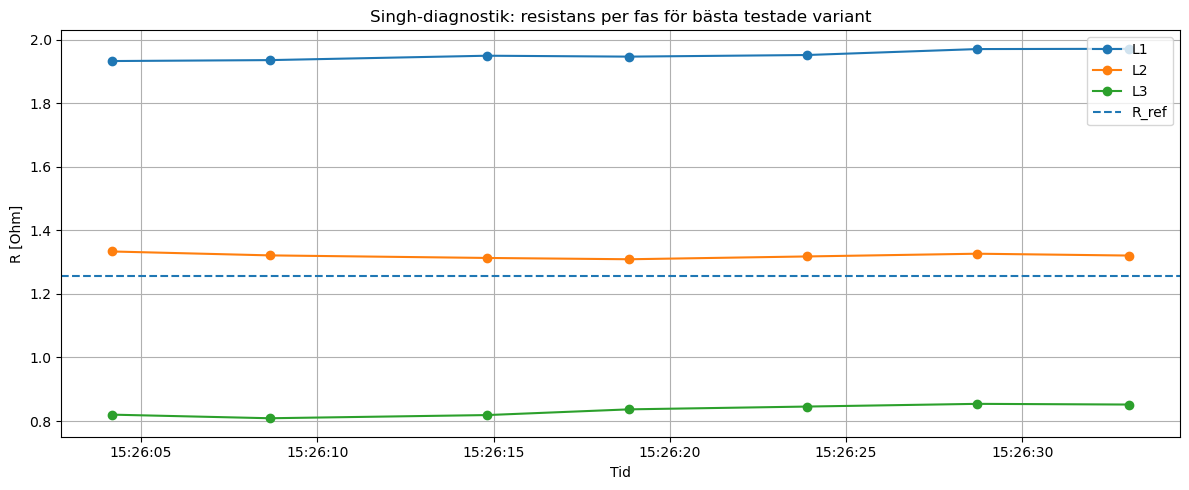

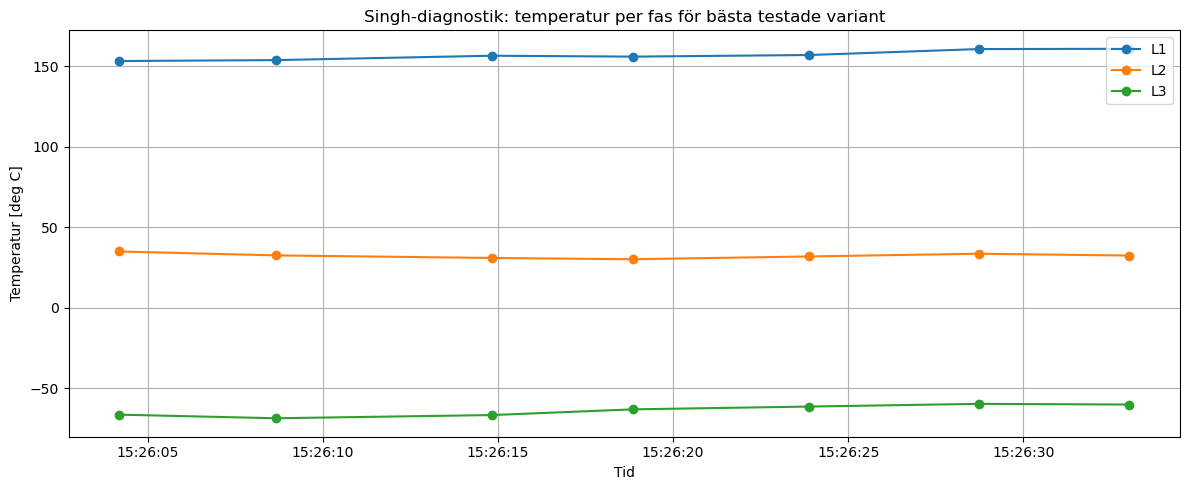

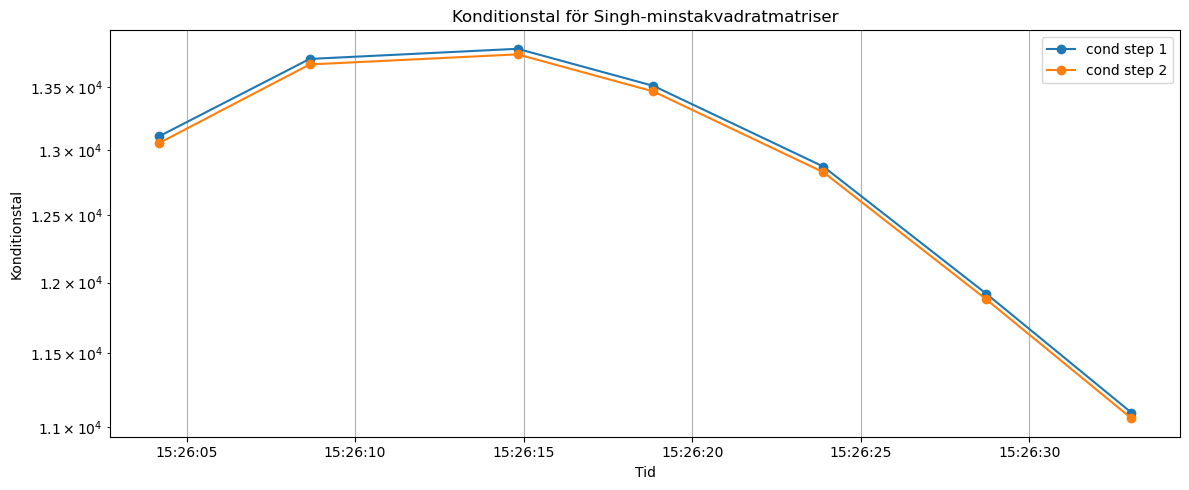

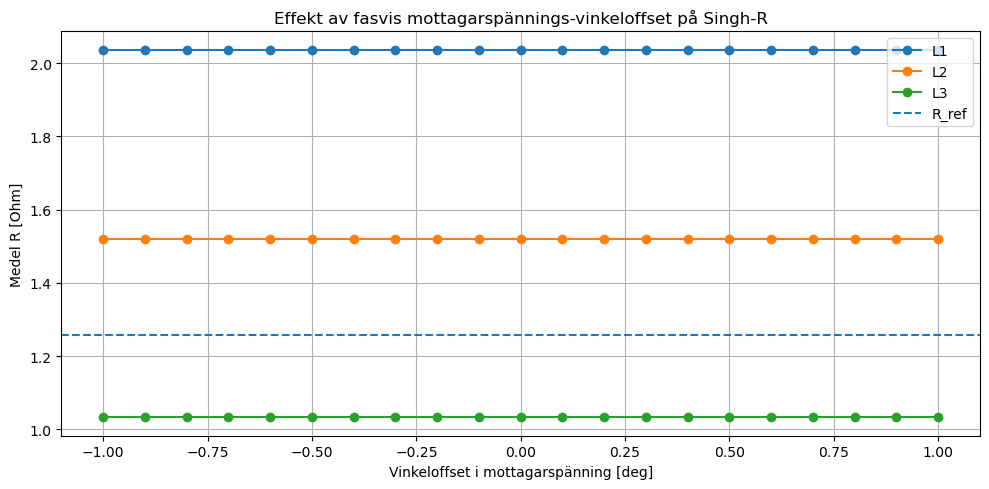


Klar.
Resultat sparade i: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\T8_Singh_diagnostics

TOLKNING

1) Om bästa fasmappning inte är L1->L1, L2->L2, L3->L3:
   Då finns misstanke om fasförväxling mellan sändar- och mottagarstation.

2) Om bästa strömtecken inte är -1 för alla faser:
   Då finns misstanke om kvarstående riktnings- eller teckenproblem i mottagarströmmen.

3) Om konditionstalen är mycket höga:
   Då är Singh-skattningen numeriskt känslig och små mätfel kan ge stora fasvisa skillnader.

4) Om signalvariationerna är mycket små:
   Då finns risk att mätperioden inte ger tillräcklig excitation för stabil parameteridentifiering.

5) Om små vinkeloffsetar flyttar R mycket:
   Då kan systematiska fasvisa vinkelbiaser förklara varför Singh ger stora skillnader mellan faser.



In [13]:

# ============================================================
# T8_Singh_diagnostics
# Diagnostik av stora fasvisa skillnader i Singh-resultatet
#
# Körs längst ner i T7_full_trefas_simultan_Singh.ipynb
# efter att df_clean har skapats.
# ============================================================

import itertools
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# ============================================================
# INSTÄLLNINGAR
# ============================================================

PHASES = ["L1", "L2", "L3"]

# Referenser som använts i arbetet
R_REF = 1.2575
X_REF = 6.555
ALPHA = 0.00403

# Originalfönster för Singh. Snabba diagnostester kan använda kortare fönster.
FULL_WINDOW_SECONDS = 120
STEP_SECONDS = 5

# Snabbdiagnostik. Öka QUICK_WINDOWS om du vill testa fler fönster.
QUICK_WINDOWS = 2
DIAG_WINDOW_SECONDS = 30

# Om True körs bästa testade variant över alla fönster med FULL_WINDOW_SECONDS.
RUN_FULL_BEST_CASE = True

# Output-mapp
try:
    base_dir = Path(send_file).parent
except Exception:
    base_dir = Path.cwd()

OUTPUT_DIR = base_dir / "T8_Singh_diagnostics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("T8 output-mapp:", OUTPUT_DIR.resolve())

# ============================================================
# KONTROLLER
# ============================================================

try:
    df_clean
except NameError:
    raise RuntimeError(
        "df_clean finns inte i minnet. Kör först T7-cellerna som läser in, pivotar och rensar mätdata."
    )

# Kontrollera att Singh-funktionerna från T7 finns
for fn_name in ["estimate_B_and_K1_3ph", "estimate_Z_and_K4_3ph"]:
    if fn_name not in globals():
        raise RuntimeError(f"Funktionen {fn_name} saknas. Kör funktionscellerna i T7 först.")

df_for_test = df_clean.copy()

# Säkerställ datetime-index
if not isinstance(df_for_test.index, pd.DatetimeIndex):
    if "Timestamp" in df_for_test.columns:
        df_for_test["Timestamp"] = pd.to_datetime(df_for_test["Timestamp"], errors="coerce")
        df_for_test = df_for_test.dropna(subset=["Timestamp"]).set_index("Timestamp")
    else:
        raise ValueError("df_clean måste ha DatetimeIndex eller en kolumn som heter Timestamp.")

required_cols = []
for ph in PHASES:
    required_cols += [
        f"U{ph}MAG_S", f"U{ph}ANG_S", f"I{ph}MAG_S", f"I{ph}ANG_S",
        f"U{ph}MAG_R", f"U{ph}ANG_R", f"I{ph}MAG_R", f"I{ph}ANG_R",
    ]

missing = [c for c in required_cols if c not in df_for_test.columns]
if missing:
    raise ValueError(f"Saknade kolumner i df_clean: {missing}")

for c in required_cols:
    df_for_test[c] = (
        df_for_test[c]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    df_for_test[c] = pd.to_numeric(df_for_test[c], errors="coerce")

df_for_test = df_for_test.dropna(subset=required_cols).copy()

print("Antal rader i df_for_test:", len(df_for_test))
print("Start:", df_for_test.index.min())
print("Slut :", df_for_test.index.max())

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def show_df(title, df, n=10):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
    try:
        display(df.head(n))
    except NameError:
        print(df.head(n))


def wrap_angle_deg(a):
    return (np.asarray(a, dtype=float) + 180.0) % 360.0 - 180.0


def circ_mean_deg(a):
    a_wrapped = wrap_angle_deg(a)
    a_rad = np.deg2rad(a_wrapped)
    return np.rad2deg(np.angle(np.nanmean(np.exp(1j * a_rad))))


def phasor_from_mag_ang(mag, ang_deg):
    mag = np.asarray(mag, dtype=float)
    ang_deg = np.asarray(ang_deg, dtype=float)
    return mag * np.exp(1j * np.deg2rad(ang_deg))


def get_sampling_frequency(df):
    dt = df.index.to_series().diff().dropna().dt.total_seconds()
    return 1.0 / dt.median()

# ============================================================
# BYGG FASORER MED VALFRI FASMAPPNING OCH STRÖMTECKEN
# ============================================================

def build_phasors_variant(
    df,
    receiver_phase_map=None,
    ir_signs=None,
    vr_angle_offsets=None,
    ir_angle_offsets=None,
):
    """
    receiver_phase_map:
        Exempel {"L1": "L1", "L2": "L2", "L3": "L3"}
        betyder att sändar-L1 paras med mottagar-L1.

    ir_signs:
        -1 = inverterad mottagarström
        +1 = rå mottagarström
    """

    if receiver_phase_map is None:
        receiver_phase_map = {ph: ph for ph in PHASES}

    if ir_signs is None:
        ir_signs = {ph: -1 for ph in PHASES}

    if vr_angle_offsets is None:
        vr_angle_offsets = {ph: 0.0 for ph in PHASES}

    if ir_angle_offsets is None:
        ir_angle_offsets = {ph: 0.0 for ph in PHASES}

    out = {}

    for ph in PHASES:
        rph = receiver_phase_map[ph]

        Vs = phasor_from_mag_ang(
            df[f"U{ph}MAG_S"],
            df[f"U{ph}ANG_S"]
        )

        Is = phasor_from_mag_ang(
            df[f"I{ph}MAG_S"],
            df[f"I{ph}ANG_S"]
        )

        Vr = phasor_from_mag_ang(
            df[f"U{rph}MAG_R"],
            df[f"U{rph}ANG_R"] + vr_angle_offsets.get(ph, 0.0)
        )

        Ir_raw = phasor_from_mag_ang(
            df[f"I{rph}MAG_R"],
            df[f"I{rph}ANG_R"] + ir_angle_offsets.get(ph, 0.0)
        )

        Ir = ir_signs.get(ph, -1) * Ir_raw

        out[ph] = {
            "Vs": pd.Series(Vs, index=df.index),
            "Vr": pd.Series(Vr, index=df.index),
            "Is": pd.Series(Is, index=df.index),
            "Ir": pd.Series(Ir, index=df.index),
        }

    return out

# ============================================================
# KÖR SINGH FÖR EN VARIANT
# ============================================================

def run_singh_variant(
    df,
    receiver_phase_map=None,
    ir_signs=None,
    vr_angle_offsets=None,
    ir_angle_offsets=None,
    window_seconds=FULL_WINDOW_SECONDS,
    step_seconds=STEP_SECONDS,
    max_windows=None,
):
    fs = get_sampling_frequency(df)
    window = int(round(window_seconds * fs))
    step = int(round(step_seconds * fs))

    n = len(df)
    if n <= window:
        raise ValueError(f"För få datapunkter för valt fönster. N={n}, window={window}")

    idx = np.arange(0, n - window + 1, step)

    if max_windows is not None:
        idx = idx[:max_windows]

    phasors_variant = build_phasors_variant(
        df,
        receiver_phase_map=receiver_phase_map,
        ir_signs=ir_signs,
        vr_angle_offsets=vr_angle_offsets,
        ir_angle_offsets=ir_angle_offsets,
    )

    rows = []
    diag_rows = []

    for i0 in idx:
        i1 = i0 + window

        vs_dict = {}
        vr_dict = {}
        is_dict = {}
        ir_dict = {}

        for ph in PHASES:
            vs_dict[ph] = phasors_variant[ph]["Vs"].iloc[i0:i1].to_numpy()
            vr_dict[ph] = phasors_variant[ph]["Vr"].iloc[i0:i1].to_numpy()
            is_dict[ph] = phasors_variant[ph]["Is"].iloc[i0:i1].to_numpy()
            ir_dict[ph] = phasors_variant[ph]["Ir"].iloc[i0:i1].to_numpy()

        try:
            res1 = estimate_B_and_K1_3ph(vs_dict, vr_dict, is_dict, ir_dict)
            beta1 = res1["beta"]

            B = {
                "L1": beta1[6],
                "L2": beta1[7],
                "L3": beta1[8],
            }

            res2 = estimate_Z_and_K4_3ph(vs_dict, vr_dict, ir_dict, B)
            beta2 = res2["beta"]

        except Exception as e:
            print("Singh failed in window", i0, "error:", e)
            continue

        center_ts = df.index[i0 + window // 2]

        try:
            cond_step1 = np.linalg.cond(res1["A"])
            cond_step2 = np.linalg.cond(res2["A"])
        except Exception:
            cond_step1 = np.nan
            cond_step2 = np.nan

        diag_rows.append({
            "Timestamp": center_ts,
            "cond_step1": cond_step1,
            "cond_step2": cond_step2,
            "rank_step1": res1["rank"],
            "rank_step2": res2["rank"],
        })

        for ph_idx, ph in enumerate(PHASES):
            R = beta2[6 + ph_idx]
            X = beta2[9 + ph_idx]
            T_est = ((R / R_REF) - 1.0) / ALPHA + 20.0

            rows.append({
                "Timestamp": center_ts,
                "Phase": ph,
                "R_Ohm": R,
                "X_Ohm": X,
                "T_C": T_est,
                "cond_step1": cond_step1,
                "cond_step2": cond_step2,
            })

    return pd.DataFrame(rows), pd.DataFrame(diag_rows)


def summarize_singh_result(result_long, label="case"):
    if result_long.empty:
        return pd.DataFrame(), {
            "label": label,
            "failed": True,
            "score": np.inf,
        }

    summary = (
        result_long
        .groupby("Phase")
        .agg(
            R_mean_Ohm=("R_Ohm", "mean"),
            R_std_Ohm=("R_Ohm", "std"),
            X_mean_Ohm=("X_Ohm", "mean"),
            X_std_Ohm=("X_Ohm", "std"),
            T_mean_C=("T_C", "mean"),
            T_std_C=("T_C", "std"),
        )
        .reset_index()
    )

    r_means = summary["R_mean_Ohm"].to_numpy()
    x_means = summary["X_mean_Ohm"].to_numpy()

    metrics = {
        "label": label,
        "R_min_mean": np.nanmin(r_means),
        "R_max_mean": np.nanmax(r_means),
        "R_phase_spread_Ohm": np.nanmax(r_means) - np.nanmin(r_means),
        "R_cv_percent": 100.0 * np.nanstd(r_means) / abs(np.nanmean(r_means)),
        "R_mean_abs_error_vs_ref": np.nanmean(np.abs(r_means - R_REF)),
        "X_mean_abs_error_vs_ref": np.nanmean(np.abs(x_means - X_REF)),
        "negative_R_count": int(np.sum(result_long["R_Ohm"] < 0)),
    }

    metrics["score"] = (
        metrics["R_phase_spread_Ohm"]
        + metrics["R_mean_abs_error_vs_ref"]
        + 100.0 * metrics["negative_R_count"]
    )

    return summary, metrics

# ============================================================
# TEST 1: FASMAPPNING OCH GLOBAL STRÖMRIKTNING
# ============================================================

def test_phase_mapping_and_current_direction(df, quick_windows=QUICK_WINDOWS):
    rows = []

    sign_cases = {
        "Ir_inverted_all": {"L1": -1, "L2": -1, "L3": -1},
        "Ir_raw_all": {"L1": 1, "L2": 1, "L3": 1},
    }

    for perm in itertools.permutations(PHASES):
        receiver_phase_map = dict(zip(PHASES, perm))

        for sign_label, ir_signs in sign_cases.items():
            label = (
                f"L1->{receiver_phase_map['L1']}, "
                f"L2->{receiver_phase_map['L2']}, "
                f"L3->{receiver_phase_map['L3']}, "
                f"{sign_label}"
            )

            result_long, diag = run_singh_variant(
                df,
                receiver_phase_map=receiver_phase_map,
                ir_signs=ir_signs,
                window_seconds=DIAG_WINDOW_SECONDS,
                max_windows=quick_windows,
            )

            summary, metrics = summarize_singh_result(result_long, label=label)

            rows.append({
                "label": label,
                "map_L1": receiver_phase_map["L1"],
                "map_L2": receiver_phase_map["L2"],
                "map_L3": receiver_phase_map["L3"],
                "current_case": sign_label,
                "R_phase_spread_Ohm": metrics.get("R_phase_spread_Ohm", np.nan),
                "R_cv_percent": metrics.get("R_cv_percent", np.nan),
                "R_mean_abs_error_vs_ref": metrics.get("R_mean_abs_error_vs_ref", np.nan),
                "X_mean_abs_error_vs_ref": metrics.get("X_mean_abs_error_vs_ref", np.nan),
                "negative_R_count": metrics.get("negative_R_count", np.nan),
                "score": metrics.get("score", np.nan),
            })

    return pd.DataFrame(rows).sort_values("score")

# ============================================================
# TEST 2: PER-FAS STRÖMTECKEN
# ============================================================

def test_all_current_sign_combinations(df, receiver_phase_map=None, quick_windows=QUICK_WINDOWS):
    if receiver_phase_map is None:
        receiver_phase_map = {"L1": "L1", "L2": "L2", "L3": "L3"}

    rows = []

    for signs_tuple in itertools.product([-1, 1], repeat=3):
        ir_signs = dict(zip(PHASES, signs_tuple))
        sign_label = "_".join([f"{ph}:{ir_signs[ph]}" for ph in PHASES])

        result_long, diag = run_singh_variant(
            df,
            receiver_phase_map=receiver_phase_map,
            ir_signs=ir_signs,
            window_seconds=DIAG_WINDOW_SECONDS,
            max_windows=quick_windows,
        )

        summary, metrics = summarize_singh_result(result_long, label=sign_label)

        rows.append({
            "signs": sign_label,
            "R_phase_spread_Ohm": metrics.get("R_phase_spread_Ohm", np.nan),
            "R_cv_percent": metrics.get("R_cv_percent", np.nan),
            "R_mean_abs_error_vs_ref": metrics.get("R_mean_abs_error_vs_ref", np.nan),
            "X_mean_abs_error_vs_ref": metrics.get("X_mean_abs_error_vs_ref", np.nan),
            "negative_R_count": metrics.get("negative_R_count", np.nan),
            "score": metrics.get("score", np.nan),
        })

    return pd.DataFrame(rows).sort_values("score")

# ============================================================
# TEST 3: FASPARINGS-MATRISER
# ============================================================

def phase_pairing_sanity_matrices(df):
    U_angle_mean = pd.DataFrame(index=PHASES, columns=PHASES, dtype=float)
    U_angle_std = pd.DataFrame(index=PHASES, columns=PHASES, dtype=float)

    I_angle_mean_corr = pd.DataFrame(index=PHASES, columns=PHASES, dtype=float)
    I_angle_std_corr = pd.DataFrame(index=PHASES, columns=PHASES, dtype=float)

    U_mag_ratio = pd.DataFrame(index=PHASES, columns=PHASES, dtype=float)
    I_mag_ratio = pd.DataFrame(index=PHASES, columns=PHASES, dtype=float)

    for sph in PHASES:
        for rph in PHASES:
            dU = wrap_angle_deg(df[f"U{sph}ANG_S"] - df[f"U{rph}ANG_R"])

            Ir_ang_corr = wrap_angle_deg(df[f"I{rph}ANG_R"] + 180.0)
            dI = wrap_angle_deg(df[f"I{sph}ANG_S"] - Ir_ang_corr)

            U_angle_mean.loc[sph, rph] = circ_mean_deg(dU)
            U_angle_std.loc[sph, rph] = np.nanstd(dU)

            I_angle_mean_corr.loc[sph, rph] = circ_mean_deg(dI)
            I_angle_std_corr.loc[sph, rph] = np.nanstd(dI)

            U_mag_ratio.loc[sph, rph] = np.nanmean(
                df[f"U{sph}MAG_S"] / df[f"U{rph}MAG_R"]
            )

            I_mag_ratio.loc[sph, rph] = np.nanmean(
                df[f"I{sph}MAG_S"] / df[f"I{rph}MAG_R"]
            )

    return {
        "U_angle_mean_deg": U_angle_mean,
        "U_angle_std_deg": U_angle_std,
        "I_angle_mean_corr_deg": I_angle_mean_corr,
        "I_angle_std_corr_deg": I_angle_std_corr,
        "U_mag_ratio": U_mag_ratio,
        "I_mag_ratio": I_mag_ratio,
    }

# ============================================================
# TEST 4: SIGNALVARIATION
# ============================================================

def signal_variation_table(df):
    rows = []

    for ph in PHASES:
        for station in ["S", "R"]:
            for quantity in ["U", "I"]:
                mag_col = f"{quantity}{ph}MAG_{station}"
                ang_col = f"{quantity}{ph}ANG_{station}"

                mag_mean = df[mag_col].mean()
                mag_std = df[mag_col].std()
                mag_cv_pct = 100.0 * mag_std / abs(mag_mean)

                ang_std = np.nanstd(
                    wrap_angle_deg(df[ang_col] - circ_mean_deg(df[ang_col]))
                )

                rows.append({
                    "Phase": ph,
                    "Station": station,
                    "Quantity": quantity,
                    "Magnitude_mean": mag_mean,
                    "Magnitude_std": mag_std,
                    "Magnitude_CV_percent": mag_cv_pct,
                    "Angle_std_deg": ang_std,
                })

    return pd.DataFrame(rows)

# ============================================================
# TEST 5: FASVIS VINKELBIAS PÅ MOTTAGARSPÄNNING
# ============================================================

def sweep_single_phase_vr_angle_offset(
    df,
    target_phase,
    offsets_deg,
    receiver_phase_map=None,
    ir_signs=None,
    quick_windows=QUICK_WINDOWS,
):
    if receiver_phase_map is None:
        receiver_phase_map = {"L1": "L1", "L2": "L2", "L3": "L3"}

    if ir_signs is None:
        ir_signs = {"L1": -1, "L2": -1, "L3": -1}

    rows = []

    for off in offsets_deg:
        vr_offsets = {"L1": 0.0, "L2": 0.0, "L3": 0.0}
        vr_offsets[target_phase] = off

        result_long, diag = run_singh_variant(
            df,
            receiver_phase_map=receiver_phase_map,
            ir_signs=ir_signs,
            vr_angle_offsets=vr_offsets,
            window_seconds=DIAG_WINDOW_SECONDS,
            max_windows=quick_windows,
        )

        if result_long.empty:
            continue

        d = result_long[result_long["Phase"] == target_phase]

        rows.append({
            "Phase": target_phase,
            "Vr_angle_offset_deg": off,
            "R_mean_Ohm": d["R_Ohm"].mean(),
            "X_mean_Ohm": d["X_Ohm"].mean(),
            "T_mean_C": d["T_C"].mean(),
        })

    return pd.DataFrame(rows)

# ============================================================
# KÖR ALLA TESTER
# ============================================================

print("\nKör TEST 1: fasmappning och global strömriktning...")
phase_mapping_test = test_phase_mapping_and_current_direction(
    df_for_test,
    quick_windows=QUICK_WINDOWS,
)
show_df("Bästa fasmappningar och global strömriktning", phase_mapping_test, n=12)

best = phase_mapping_test.iloc[0]
best_receiver_phase_map = {
    "L1": best["map_L1"],
    "L2": best["map_L2"],
    "L3": best["map_L3"],
}

if best["current_case"] == "Ir_inverted_all":
    best_ir_signs_global = {"L1": -1, "L2": -1, "L3": -1}
else:
    best_ir_signs_global = {"L1": 1, "L2": 1, "L3": 1}

print("\nBästa fasmappning enligt enkel score:")
print(best_receiver_phase_map)
print("Bästa globalt strömtecken:", best["current_case"])

print("\nKör TEST 2: per-fas strömtecken för bästa fasmappning...")
current_sign_test = test_all_current_sign_combinations(
    df_for_test,
    receiver_phase_map=best_receiver_phase_map,
    quick_windows=QUICK_WINDOWS,
)
show_df("Per-fas strömtecken", current_sign_test, n=10)

best_sign_row = current_sign_test.iloc[0]
best_ir_signs = {}
for item in best_sign_row["signs"].split("_"):
    ph, sign = item.split(":")
    best_ir_signs[ph] = int(sign)

print("\nBästa per-fas strömtecken enligt enkel score:")
print(best_ir_signs)

print("\nKör TEST 3: fasparningsmatriser...")
sanity = phase_pairing_sanity_matrices(df_for_test)

for name, table in sanity.items():
    show_df(name, table.round(6), n=10)

print("\nKör TEST 4: signalvariation...")
variation_stats = signal_variation_table(df_for_test)
show_df("Signalvariation", variation_stats.round(6), n=20)

print("\nKör bästa Singh-variant med alla fönster...")
if RUN_FULL_BEST_CASE:
    best_result_long, best_diag = run_singh_variant(
        df_for_test,
        receiver_phase_map=best_receiver_phase_map,
        ir_signs=best_ir_signs,
        window_seconds=FULL_WINDOW_SECONDS,
        max_windows=None,
    )
else:
    best_result_long, best_diag = run_singh_variant(
        df_for_test,
        receiver_phase_map=best_receiver_phase_map,
        ir_signs=best_ir_signs,
        window_seconds=DIAG_WINDOW_SECONDS,
        max_windows=QUICK_WINDOWS,
    )

best_summary, best_metrics = summarize_singh_result(best_result_long, label="best_case")

show_df("Sammanfattning för bästa Singh-variant", best_summary.round(6), n=10)
show_df("Mått för bästa Singh-variant", pd.DataFrame([best_metrics]).round(6), n=10)

print("\nKör TEST 5: fasvisa mottagarspännings-vinkeloffsetar...")
offsets = np.linspace(-1.0, 1.0, 21)

angle_bias_rows = []
for ph in PHASES:
    tmp = sweep_single_phase_vr_angle_offset(
        df_for_test,
        target_phase=ph,
        offsets_deg=offsets,
        receiver_phase_map=best_receiver_phase_map,
        ir_signs=best_ir_signs,
        quick_windows=QUICK_WINDOWS,
    )
    angle_bias_rows.append(tmp)

angle_bias_test = pd.concat(angle_bias_rows, ignore_index=True)
show_df("Vinkelbias-test på Vr", angle_bias_test.round(6), n=20)

# ============================================================
# PLOTTAR
# ============================================================

plt.figure(figsize=(12, 5))
for ph in PHASES:
    d = best_result_long[best_result_long["Phase"] == ph]
    plt.plot(d["Timestamp"], d["R_Ohm"], marker="o", label=ph)

plt.axhline(R_REF, linestyle="--", label="R_ref")
plt.title("Singh-diagnostik: resistans per fas för bästa testade variant")
plt.xlabel("Tid")
plt.ylabel("R [Ohm]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "singh_best_variant_R_per_phase.png", dpi=200)
plt.show()

plt.figure(figsize=(12, 5))
for ph in PHASES:
    d = best_result_long[best_result_long["Phase"] == ph]
    plt.plot(d["Timestamp"], d["T_C"], marker="o", label=ph)

plt.title("Singh-diagnostik: temperatur per fas för bästa testade variant")
plt.xlabel("Tid")
plt.ylabel("Temperatur [deg C]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "singh_best_variant_T_per_phase.png", dpi=200)
plt.show()

plt.figure(figsize=(12, 5))
plt.semilogy(best_diag["Timestamp"], best_diag["cond_step1"], marker="o", label="cond step 1")
plt.semilogy(best_diag["Timestamp"], best_diag["cond_step2"], marker="o", label="cond step 2")
plt.title("Konditionstal för Singh-minstakvadratmatriser")
plt.xlabel("Tid")
plt.ylabel("Konditionstal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "singh_condition_numbers.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
for ph in PHASES:
    d = angle_bias_test[angle_bias_test["Phase"] == ph]
    plt.plot(d["Vr_angle_offset_deg"], d["R_mean_Ohm"], marker="o", label=ph)

plt.axhline(R_REF, linestyle="--", label="R_ref")
plt.title("Effekt av fasvis mottagarspännings-vinkeloffset på Singh-R")
plt.xlabel("Vinkeloffset i mottagarspänning [deg]")
plt.ylabel("Medel R [Ohm]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "singh_vr_angle_offset_effect_on_R.png", dpi=200)
plt.show()

# ============================================================
# SPARA RESULTAT
# ============================================================

phase_mapping_test.to_csv(OUTPUT_DIR / "phase_mapping_test.csv", index=False)
current_sign_test.to_csv(OUTPUT_DIR / "current_sign_test.csv", index=False)
variation_stats.to_csv(OUTPUT_DIR / "signal_variation_stats.csv", index=False)
best_result_long.to_csv(OUTPUT_DIR / "best_singh_result_long.csv", index=False)
best_diag.to_csv(OUTPUT_DIR / "best_singh_diagnostics.csv", index=False)
angle_bias_test.to_csv(OUTPUT_DIR / "angle_bias_test.csv", index=False)
best_summary.to_csv(OUTPUT_DIR / "best_singh_summary.csv", index=False)

with pd.ExcelWriter(OUTPUT_DIR / "singh_diagnostics_summary.xlsx", engine="openpyxl") as writer:
    phase_mapping_test.to_excel(writer, sheet_name="phase_mapping", index=False)
    current_sign_test.to_excel(writer, sheet_name="current_signs", index=False)
    variation_stats.to_excel(writer, sheet_name="signal_variation", index=False)
    best_result_long.to_excel(writer, sheet_name="best_result_long", index=False)
    best_diag.to_excel(writer, sheet_name="condition_numbers", index=False)
    angle_bias_test.to_excel(writer, sheet_name="angle_bias_test", index=False)
    best_summary.to_excel(writer, sheet_name="best_summary", index=False)

    for name, table in sanity.items():
        safe_name = name[:31]
        table.to_excel(writer, sheet_name=safe_name)

print("\nKlar.")
print("Resultat sparade i:", OUTPUT_DIR.resolve())

# ============================================================
# SNABB TOLKNINGSHJÄLP
# ============================================================

print("\n" + "=" * 80)
print("TOLKNING")
print("=" * 80)

print("""
1) Om bästa fasmappning inte är L1->L1, L2->L2, L3->L3:
   Då finns misstanke om fasförväxling mellan sändar- och mottagarstation.

2) Om bästa strömtecken inte är -1 för alla faser:
   Då finns misstanke om kvarstående riktnings- eller teckenproblem i mottagarströmmen.

3) Om konditionstalen är mycket höga:
   Då är Singh-skattningen numeriskt känslig och små mätfel kan ge stora fasvisa skillnader.

4) Om signalvariationerna är mycket små:
   Då finns risk att mätperioden inte ger tillräcklig excitation för stabil parameteridentifiering.

5) Om små vinkeloffsetar flyttar R mycket:
   Då kan systematiska fasvisa vinkelbiaser förklara varför Singh ger stora skillnader mellan faser.
""")


Använder fasmappning: {'L1': 'L1', 'L2': 'L2', 'L3': 'L3'}
Använder mottagarströmtecken: {'L1': -1, 'L2': -1, 'L3': -1}
Extra output-mapp: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\T8_Singh_diagnostics\extra_angle_diagnostics
Kör mode: vr_only_phase
Kör mode: ir_only_phase
Kör mode: station_common_phase
Kör mode: local_vi_phase
Kör mode: station_common_all
Kör mode: ir_only_all

Extra vinkeltest - resultat


,Mode,Affected_phase,Offset_deg,Result_phase,R_mean_Ohm,R_std_Ohm,X_mean_Ohm,X_std_Ohm,T_mean_C,T_std_C,R_phase_spread_Ohm
0,vr_only_phase,L1,-1.0,L1,1.933737,0.002074,6.393472,0.025048,153.439998,0.409343,1.119376
1,vr_only_phase,L1,-1.0,L2,1.327118,0.008681,5.972224,0.031487,33.737469,1.713049,1.119376
2,vr_only_phase,L1,-1.0,L3,0.814361,0.008008,6.354381,0.025561,-67.443321,1.580214,1.119376
3,vr_only_phase,L1,-0.5,L1,1.933737,0.002074,6.393472,0.025048,153.439998,0.409343,1.119376
4,vr_only_phase,L1,-0.5,L2,1.327118,0.008681,5.972224,0.031487,33.737469,1.713049,1.119376
5,vr_only_phase,L1,-0.5,L3,0.814361,0.008008,6.354381,0.025561,-67.443321,1.580214,1.119376
6,vr_only_phase,L1,-0.2,L1,1.933737,0.002074,6.393472,0.025048,153.439998,0.409343,1.119376
7,vr_only_phase,L1,-0.2,L2,1.327118,0.008681,5.972224,0.031487,33.737469,1.713049,1.119376
8,vr_only_phase,L1,-0.2,L3,0.814361,0.008008,6.354381,0.025561,-67.443321,1.580214,1.119376
9,vr_only_phase,L1,-0.1,L1,1.933737,0.002074,6.393472,0.025048,153.439998,0.409343,1.119376



Central lutning nära noll offset


,Mode,Affected_phase,Result_phase,Offset_minus_deg,Offset_plus_deg,dR_ddeg_Ohm_per_deg,dX_ddeg_Ohm_per_deg,dT_ddeg_C_per_deg,abs_dT_ddeg_C_per_deg
0,ir_only_all,ALL,L1,-0.1,0.1,0.111587,-0.033750,22.019167,22.019167
1,ir_only_all,ALL,L2,-0.1,0.1,0.104235,-0.023163,20.568386,20.568386
2,ir_only_all,ALL,L3,-0.1,0.1,0.110905,-0.014213,21.884538,21.884538
3,ir_only_phase,L1,L1,-0.1,0.1,0.111587,-0.033750,22.019167,22.019167
4,ir_only_phase,L1,L2,-0.1,0.1,-0.000000,-0.000000,-0.000000,0.000000
5,ir_only_phase,L1,L3,-0.1,0.1,-0.000000,-0.000000,-0.000000,0.000000
6,ir_only_phase,L2,L1,-0.1,0.1,0.000000,0.000000,0.000000,0.000000
7,ir_only_phase,L2,L2,-0.1,0.1,0.104235,-0.023163,20.568386,20.568386
8,ir_only_phase,L2,L3,-0.1,0.1,-0.000000,0.000000,-0.000000,0.000000
9,ir_only_phase,L3,L1,-0.1,0.1,-0.000000,0.000000,-0.000000,0.000000



Största absolut temperaturkänslighet per mode


,Mode,Affected_phase,max_abs_dT_ddeg_C_per_deg,phase_with_max
0,ir_only_all,ALL,22.019167,L1
1,ir_only_phase,L1,22.019167,L1
8,station_common_phase,L1,22.019167,L1
7,station_common_all,ALL,22.019167,L1
3,ir_only_phase,L3,21.884538,L1
10,station_common_phase,L3,21.884538,L1
9,station_common_phase,L2,20.568386,L1
2,ir_only_phase,L2,20.568386,L1
4,local_vi_phase,L1,11.009587,L1
6,local_vi_phase,L3,10.942273,L1


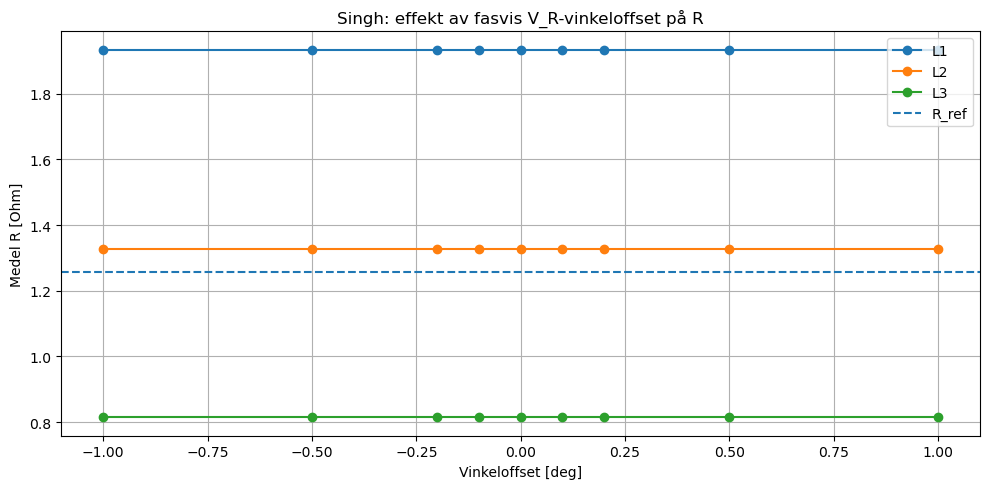

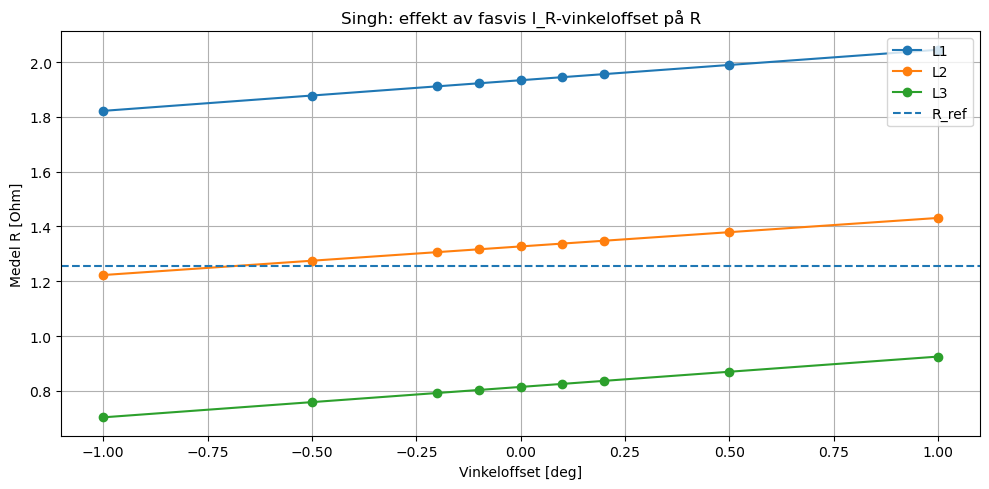

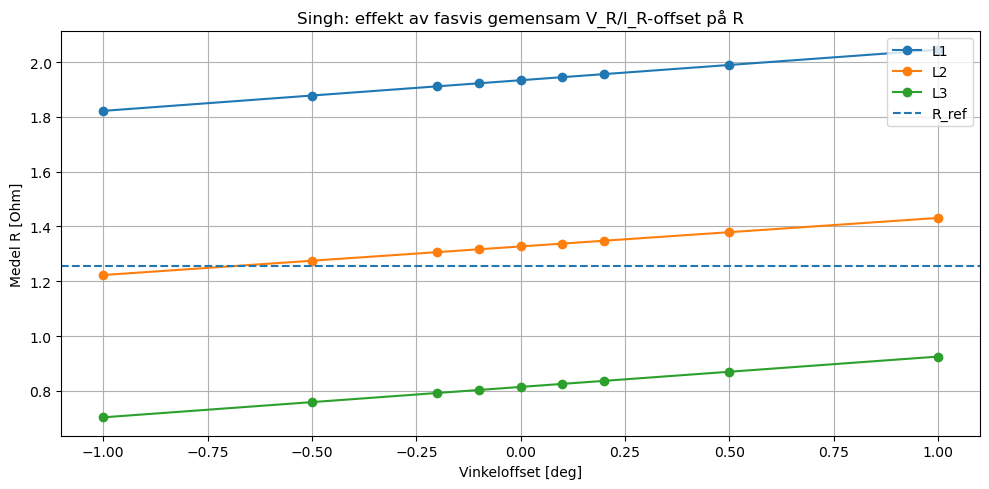

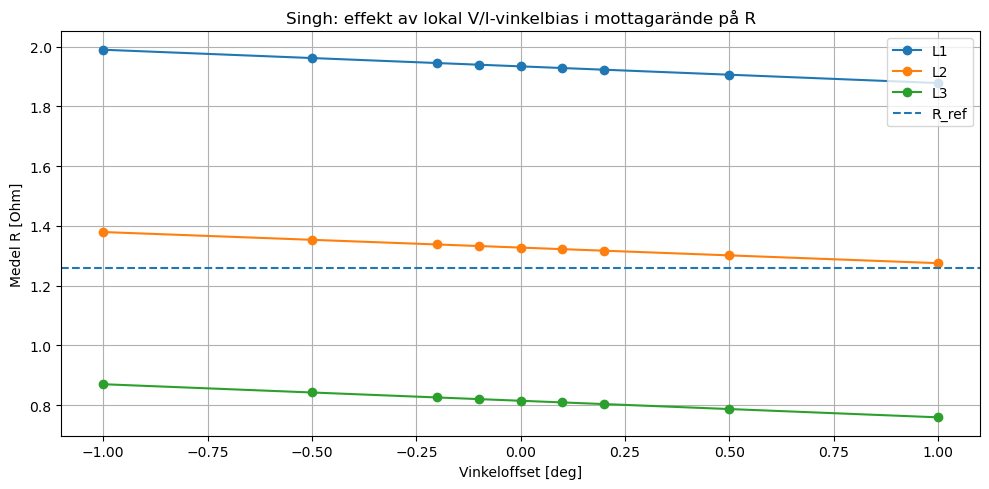

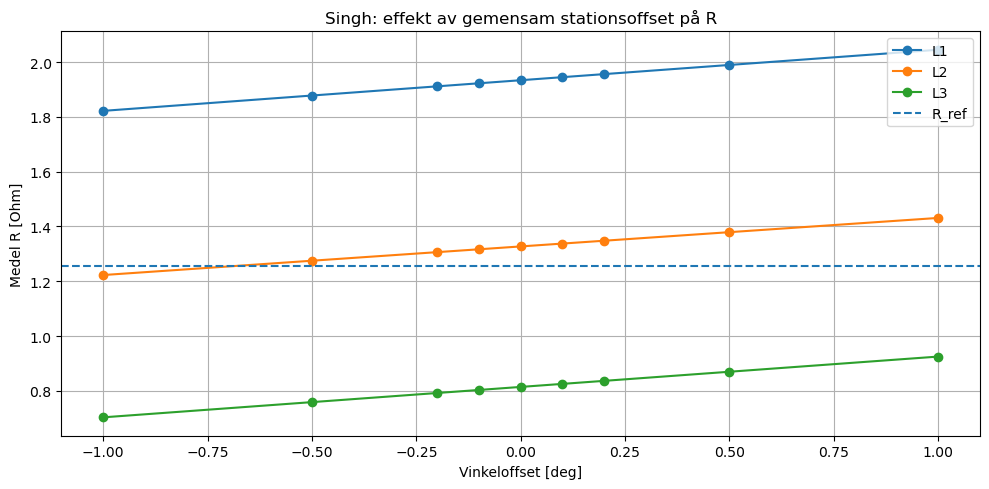

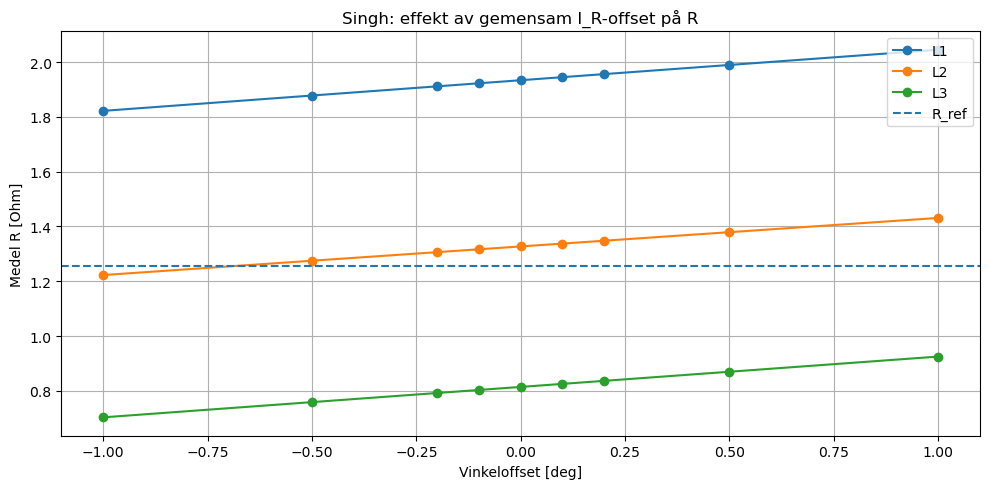


Klar.
Resultat sparade i: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\T8_Singh_diagnostics\extra_angle_diagnostics

TOLKNINGSHJÄLP

Titta särskilt på tabellen 'Största absolut temperaturkänslighet per mode':

- Om ir_only_phase eller ir_only_all är stor:
  Då är Singh känslig för mottagarströmmens vinkel.

- Om station_common_all är liten:
  Då påverkar en ren gemensam stationsrotation inte mycket.

- Om local_vi_phase är stor:
  Då är lokal V/I-vinkelbias i mottagaränden en möjlig förklaring till fasvisa R-skillnader.

- Om vr_only_phase är platt:
  Då stämmer tidigare observation att V_R-only offset absorberas av modellen och inte förklarar R-skillnaden.

Viktigast:
Om ingen av dessa offsetar reducerar fasnivåerna till liknande R, men känsligheten är hög,
kan slutsatsen bli att Singh-resultatet domineras av systematiska fasvisa mätkedje-/modellskillnader
snarare än verkliga temperaturskillnader.



In [14]:
# ============================================================
# T8 EXTRA: VINKELDIAGNOSTIK FÖR SINGH
# ============================================================
# Syfte:
#   Undersöka om stora fasvisa skillnader i Singh-R kan bero på:
#   1) vinkeloffset endast i mottagarströmmen
#   2) gemensam stationsoffset i mottagarstationen
#   3) lokal V/I-vinkelbias i mottagaränden
#   4) jämförelse mot mottagarspänning-only
#
# Kör denna cell efter att T8-diagnostiken redan har definierat:
#   df_for_test eller df_clean
#   run_singh_variant()
#   best_receiver_phase_map
#   best_ir_signs
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# ------------------------------------------------------------
# Säkerhetskontroller och defaults
# ------------------------------------------------------------

try:
    df_extra = df_for_test.copy()
except NameError:
    try:
        df_extra = df_clean.copy()
    except NameError:
        raise RuntimeError("Varken df_for_test eller df_clean finns. Kör först datacellerna/T8-diagnostiken.")

try:
    PHASES
except NameError:
    PHASES = ["L1", "L2", "L3"]

try:
    R_REF
except NameError:
    R_REF = 1.2575

try:
    X_REF
except NameError:
    X_REF = 6.555

try:
    ALPHA
except NameError:
    ALPHA = 0.00403

try:
    best_receiver_phase_map
except NameError:
    best_receiver_phase_map = {"L1": "L1", "L2": "L2", "L3": "L3"}

try:
    best_ir_signs
except NameError:
    best_ir_signs = {"L1": -1, "L2": -1, "L3": -1}

try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = Path("T8_Singh_diagnostics")

OUTPUT_DIR = Path(OUTPUT_DIR)
EXTRA_DIR = OUTPUT_DIR / "extra_angle_diagnostics"
EXTRA_DIR.mkdir(parents=True, exist_ok=True)

# Snabbinställning.
# 1 = snabbare, 2 = bättre, None = alla fönster men långsammare.
QUICK_WINDOWS_EXTRA = 2

# Offsetar som testas
OFFSETS_DEG = np.array([-1.0, -0.5, -0.2, -0.1, 0.0, 0.1, 0.2, 0.5, 1.0])

print("Använder fasmappning:", best_receiver_phase_map)
print("Använder mottagarströmtecken:", best_ir_signs)
print("Extra output-mapp:", EXTRA_DIR.resolve())


# ------------------------------------------------------------
# Hjälpfunktioner
# ------------------------------------------------------------

def _display(title, df, n=20):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)
    try:
        display(df.head(n))
    except NameError:
        print(df.head(n))


def _summarize_result_long(result_long):
    """
    Sammanfattar Singh-resultat per fas.
    """
    if result_long is None or result_long.empty:
        return pd.DataFrame()

    return (
        result_long
        .groupby("Phase")
        .agg(
            R_mean_Ohm=("R_Ohm", "mean"),
            R_std_Ohm=("R_Ohm", "std"),
            X_mean_Ohm=("X_Ohm", "mean"),
            X_std_Ohm=("X_Ohm", "std"),
            T_mean_C=("T_C", "mean"),
            T_std_C=("T_C", "std"),
        )
        .reset_index()
    )


def _run_offset_case(mode, offset_deg, affected_phase="ALL"):
    """
    Kör Singh med olika typer av vinkeloffset.

    mode:
        vr_only_phase:
            Endast V_R i en fas roteras med offset_deg.

        ir_only_phase:
            Endast I_R i en fas roteras med offset_deg.

        station_common_phase:
            Både V_R och I_R i en fas roteras med offset_deg.
            Testar fasvis station-/kanaloffset där lokal V-I-vinkel inte ändras.

        local_vi_phase:
            Lokal V/I-bias i mottagaränden.
            V_R roteras +offset/2 och I_R roteras -offset/2 i en fas.
            Då ändras lokal vinkel mellan V_R och I_R med offset_deg.

        station_common_all:
            Alla V_R och I_R roteras med samma offset_deg.
            Testar gemensam station-till-station-vinkeloffset.

        ir_only_all:
            Alla I_R roteras med samma offset_deg.
            Testar gemensam strömkanaloffset i mottagarstationen.
    """

    vr_offsets = {ph: 0.0 for ph in PHASES}
    ir_offsets = {ph: 0.0 for ph in PHASES}

    if mode == "vr_only_phase":
        vr_offsets[affected_phase] = offset_deg

    elif mode == "ir_only_phase":
        ir_offsets[affected_phase] = offset_deg

    elif mode == "station_common_phase":
        vr_offsets[affected_phase] = offset_deg
        ir_offsets[affected_phase] = offset_deg

    elif mode == "local_vi_phase":
        vr_offsets[affected_phase] = offset_deg / 2.0
        ir_offsets[affected_phase] = -offset_deg / 2.0

    elif mode == "station_common_all":
        vr_offsets = {ph: offset_deg for ph in PHASES}
        ir_offsets = {ph: offset_deg for ph in PHASES}

    elif mode == "ir_only_all":
        ir_offsets = {ph: offset_deg for ph in PHASES}

    else:
        raise ValueError(f"Okänt mode: {mode}")

    result_long, diag = run_singh_variant(
        df_extra,
        receiver_phase_map=best_receiver_phase_map,
        ir_signs=best_ir_signs,
        vr_angle_offsets=vr_offsets,
        ir_angle_offsets=ir_offsets,
        max_windows=QUICK_WINDOWS_EXTRA,
    )

    summary = _summarize_result_long(result_long)

    rows = []

    if summary.empty:
        return rows

    r_spread = summary["R_mean_Ohm"].max() - summary["R_mean_Ohm"].min()

    for _, row in summary.iterrows():
        rows.append({
            "Mode": mode,
            "Affected_phase": affected_phase,
            "Offset_deg": offset_deg,
            "Result_phase": row["Phase"],
            "R_mean_Ohm": row["R_mean_Ohm"],
            "R_std_Ohm": row["R_std_Ohm"],
            "X_mean_Ohm": row["X_mean_Ohm"],
            "X_std_Ohm": row["X_std_Ohm"],
            "T_mean_C": row["T_mean_C"],
            "T_std_C": row["T_std_C"],
            "R_phase_spread_Ohm": r_spread,
        })

    return rows


def run_extended_angle_diagnostics():
    """
    Kör alla extra vinkeltester.
    """
    all_rows = []

    phase_modes = [
        "vr_only_phase",
        "ir_only_phase",
        "station_common_phase",
        "local_vi_phase",
    ]

    all_phase_modes = [
        "station_common_all",
        "ir_only_all",
    ]

    # Fasvisa tester
    for mode in phase_modes:
        print(f"Kör mode: {mode}")
        for affected_phase in PHASES:
            for off in OFFSETS_DEG:
                rows = _run_offset_case(
                    mode=mode,
                    offset_deg=float(off),
                    affected_phase=affected_phase,
                )
                all_rows.extend(rows)

    # Alla-faser-samtidigt-tester
    for mode in all_phase_modes:
        print(f"Kör mode: {mode}")
        for off in OFFSETS_DEG:
            rows = _run_offset_case(
                mode=mode,
                offset_deg=float(off),
                affected_phase="ALL",
            )
            all_rows.extend(rows)

    return pd.DataFrame(all_rows)


def calculate_central_slopes(results):
    """
    Beräknar lutning nära noll offset med central differens.
    Använder närmaste negativa och positiva offset runt noll.
    """
    slope_rows = []

    group_cols = ["Mode", "Affected_phase", "Result_phase"]

    for keys, g in results.groupby(group_cols):
        mode, affected_phase, result_phase = keys

        g = g.sort_values("Offset_deg").copy()

        g_neg = g[g["Offset_deg"] < 0]
        g_pos = g[g["Offset_deg"] > 0]

        if g_neg.empty or g_pos.empty:
            continue

        neg_row = g_neg.iloc[(g_neg["Offset_deg"].abs()).argmin()]
        pos_row = g_pos.iloc[(g_pos["Offset_deg"].abs()).argmin()]

        dx = pos_row["Offset_deg"] - neg_row["Offset_deg"]
        if dx == 0:
            continue

        dR_ddeg = (pos_row["R_mean_Ohm"] - neg_row["R_mean_Ohm"]) / dx
        dT_ddeg = (pos_row["T_mean_C"] - neg_row["T_mean_C"]) / dx
        dX_ddeg = (pos_row["X_mean_Ohm"] - neg_row["X_mean_Ohm"]) / dx

        slope_rows.append({
            "Mode": mode,
            "Affected_phase": affected_phase,
            "Result_phase": result_phase,
            "Offset_minus_deg": neg_row["Offset_deg"],
            "Offset_plus_deg": pos_row["Offset_deg"],
            "dR_ddeg_Ohm_per_deg": dR_ddeg,
            "dX_ddeg_Ohm_per_deg": dX_ddeg,
            "dT_ddeg_C_per_deg": dT_ddeg,
            "abs_dT_ddeg_C_per_deg": abs(dT_ddeg),
        })

    slopes = pd.DataFrame(slope_rows)

    if slopes.empty:
        return slopes, pd.DataFrame()

    max_slopes = (
        slopes
        .groupby(["Mode", "Affected_phase"])
        .agg(
            max_abs_dT_ddeg_C_per_deg=("abs_dT_ddeg_C_per_deg", "max"),
            phase_with_max=("Result_phase", lambda x: x.iloc[0])
        )
        .reset_index()
        .sort_values("max_abs_dT_ddeg_C_per_deg", ascending=False)
    )

    return slopes, max_slopes


def plot_phase_mode_same_phase(results, mode, title, filename):
    """
    För fasvisa tester: plotta den fas som faktiskt offsetades.
    Exempel: affected_phase = L1 och result_phase = L1.
    """
    d = results[
        (results["Mode"] == mode)
        & (results["Affected_phase"] != "ALL")
        & (results["Affected_phase"] == results["Result_phase"])
    ].copy()

    if d.empty:
        print("Ingen data för", mode)
        return

    plt.figure(figsize=(10, 5))
    for ph in PHASES:
        dd = d[d["Affected_phase"] == ph]
        plt.plot(dd["Offset_deg"], dd["R_mean_Ohm"], marker="o", label=ph)

    plt.axhline(R_REF, linestyle="--", label="R_ref")
    plt.title(title)
    plt.xlabel("Vinkeloffset [deg]")
    plt.ylabel("Medel R [Ohm]")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(EXTRA_DIR / filename, dpi=200)
    plt.show()


def plot_all_phase_mode(results, mode, title, filename):
    """
    För tester där alla faser påverkas samtidigt.
    """
    d = results[
        (results["Mode"] == mode)
        & (results["Affected_phase"] == "ALL")
    ].copy()

    if d.empty:
        print("Ingen data för", mode)
        return

    plt.figure(figsize=(10, 5))
    for ph in PHASES:
        dd = d[d["Result_phase"] == ph]
        plt.plot(dd["Offset_deg"], dd["R_mean_Ohm"], marker="o", label=ph)

    plt.axhline(R_REF, linestyle="--", label="R_ref")
    plt.title(title)
    plt.xlabel("Vinkeloffset [deg]")
    plt.ylabel("Medel R [Ohm]")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(EXTRA_DIR / filename, dpi=200)
    plt.show()


# ------------------------------------------------------------
# Kör testerna
# ------------------------------------------------------------

extended_angle_results = run_extended_angle_diagnostics()

_display("Extra vinkeltest - resultat", extended_angle_results.round(6), n=30)

angle_slopes, angle_max_slopes = calculate_central_slopes(extended_angle_results)

_display("Central lutning nära noll offset", angle_slopes.round(6), n=30)
_display("Största absolut temperaturkänslighet per mode", angle_max_slopes.round(6), n=30)

# ------------------------------------------------------------
# Plotta huvudresultat
# ------------------------------------------------------------

plot_phase_mode_same_phase(
    extended_angle_results,
    mode="vr_only_phase",
    title="Singh: effekt av fasvis V_R-vinkeloffset på R",
    filename="singh_vr_only_phase_offset_R.png",
)

plot_phase_mode_same_phase(
    extended_angle_results,
    mode="ir_only_phase",
    title="Singh: effekt av fasvis I_R-vinkeloffset på R",
    filename="singh_ir_only_phase_offset_R.png",
)

plot_phase_mode_same_phase(
    extended_angle_results,
    mode="station_common_phase",
    title="Singh: effekt av fasvis gemensam V_R/I_R-offset på R",
    filename="singh_station_common_phase_offset_R.png",
)

plot_phase_mode_same_phase(
    extended_angle_results,
    mode="local_vi_phase",
    title="Singh: effekt av lokal V/I-vinkelbias i mottagarände på R",
    filename="singh_local_vi_phase_offset_R.png",
)

plot_all_phase_mode(
    extended_angle_results,
    mode="station_common_all",
    title="Singh: effekt av gemensam stationsoffset på R",
    filename="singh_station_common_all_offset_R.png",
)

plot_all_phase_mode(
    extended_angle_results,
    mode="ir_only_all",
    title="Singh: effekt av gemensam I_R-offset på R",
    filename="singh_ir_only_all_offset_R.png",
)

# ------------------------------------------------------------
# Spara resultat
# ------------------------------------------------------------

extended_angle_results.to_csv(EXTRA_DIR / "extended_angle_results.csv", index=False)
angle_slopes.to_csv(EXTRA_DIR / "extended_angle_slopes.csv", index=False)
angle_max_slopes.to_csv(EXTRA_DIR / "extended_angle_max_slopes.csv", index=False)

with pd.ExcelWriter(EXTRA_DIR / "extended_angle_diagnostics.xlsx", engine="openpyxl") as writer:
    extended_angle_results.to_excel(writer, sheet_name="results", index=False)
    angle_slopes.to_excel(writer, sheet_name="central_slopes", index=False)
    angle_max_slopes.to_excel(writer, sheet_name="max_slopes", index=False)

print("\nKlar.")
print("Resultat sparade i:", EXTRA_DIR.resolve())

# ------------------------------------------------------------
# Kort automatisk tolkningshjälp
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("TOLKNINGSHJÄLP")
print("=" * 90)

print("""
Titta särskilt på tabellen 'Största absolut temperaturkänslighet per mode':

- Om ir_only_phase eller ir_only_all är stor:
  Då är Singh känslig för mottagarströmmens vinkel.

- Om station_common_all är liten:
  Då påverkar en ren gemensam stationsrotation inte mycket.

- Om local_vi_phase är stor:
  Då är lokal V/I-vinkelbias i mottagaränden en möjlig förklaring till fasvisa R-skillnader.

- Om vr_only_phase är platt:
  Då stämmer tidigare observation att V_R-only offset absorberas av modellen och inte förklarar R-skillnaden.

Viktigast:
Om ingen av dessa offsetar reducerar fasnivåerna till liknande R, men känsligheten är hög,
kan slutsatsen bli att Singh-resultatet domineras av systematiska fasvisa mätkedje-/modellskillnader
snarare än verkliga temperaturskillnader.
""")